____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

_______
# Count 

In [4]:
# At the surface
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]
DS = dataset_coloc_combs(comb_list, nearest=True)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSS = DS.where(DS.depth==0, drop=True)

# At 15m
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]
DS = dataset_coloc_combs(comb_list, nearest=True)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<12).dropna('row_number')
DSD = DS.where(DS.depth==15, drop=True)


nofilter__swot250naive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_0era5
Identified SWOT and drifter outliers have been removed
nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [5]:
DSD50 =  DS.where(DS.depth==50, drop=True)
DSD100 =  DS.where(DS.depth==100, drop=True)
print('Nb coloc SWOT 250m : all, surface, 15m, 50m, 100m')
print(len(DS.isel(id_comb=0).to_dataframe().dropna()),
      len(DSS.isel(id_comb=0).to_dataframe().dropna()),
      len(DSD.isel(id_comb=0).to_dataframe().dropna()),
      len(DSD50.isel(id_comb=0).to_dataframe().dropna()),
      len(DSD100.isel(id_comb=0).to_dataframe().dropna()),
     )
print('Nb coloc SWOT 2km : all, surface, 15m, 50m, 100m')
print(len(DS.isel(id_comb=1).to_dataframe().dropna()),
      len(DSS.isel(id_comb=1).to_dataframe().dropna()),
      len(DSD.isel(id_comb=1).to_dataframe().dropna()),
      len(DSD50.isel(id_comb=1).to_dataframe().dropna()),
      len(DSD100.isel(id_comb=1).to_dataframe().dropna()),
     )


Nb coloc SWOT 250m : all, surface, 15m, 50m, 100m
2117 1154 857 46 60
Nb coloc SWOT 2km : all, surface, 15m, 50m, 100m
2117 1154 857 46 60


__________________
## Sensitivity to SWOT-250m filtering

1154
10.006177572361553
10.730419456406
9.370520126609202
9.44627112381345
8.345433443650908
8.987444556305562
7.685689749342491
7.810986422227874


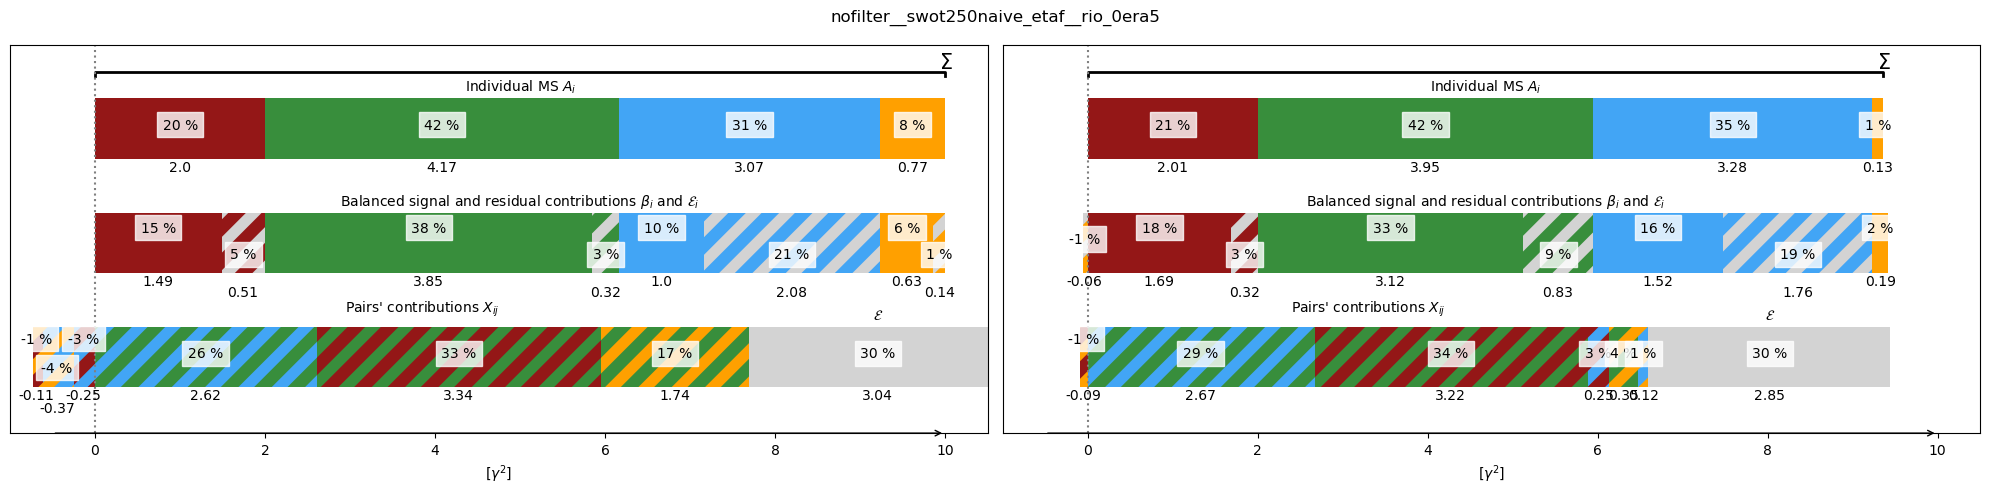

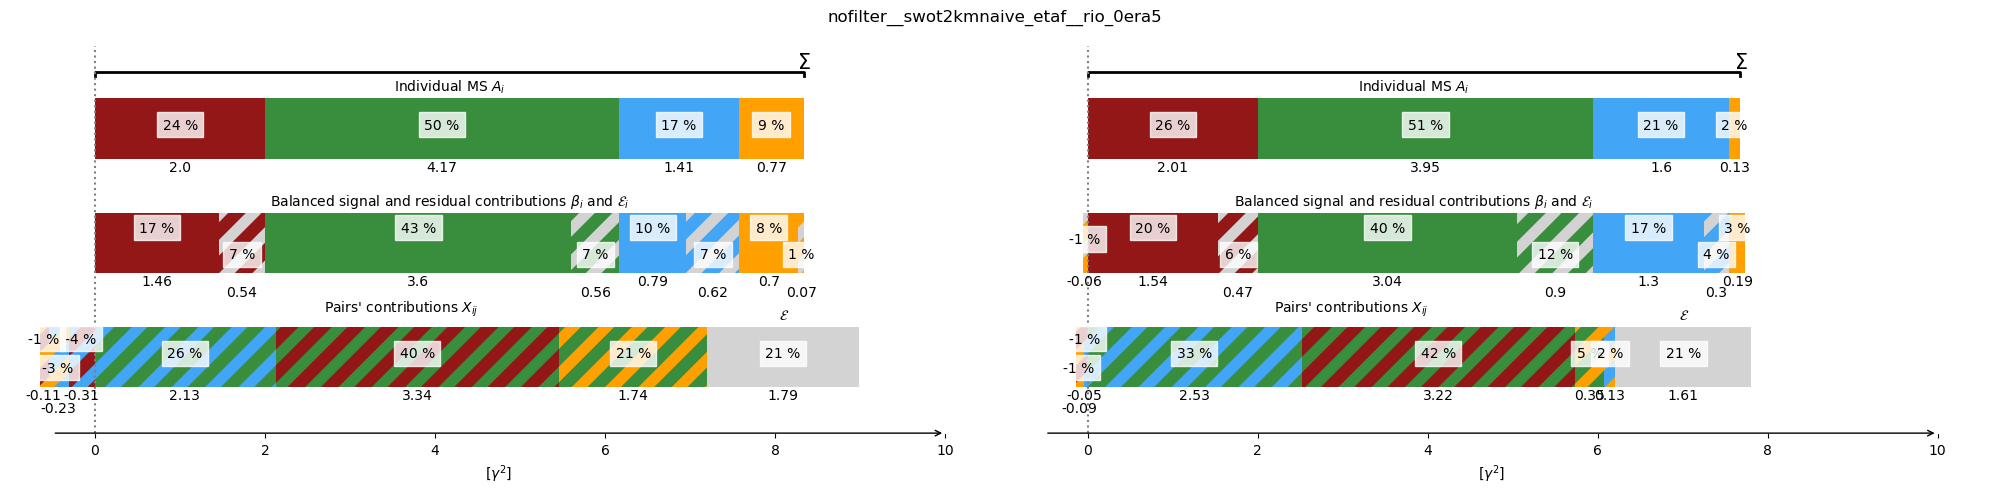

In [6]:
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

857
5.803979117618005
5.877429266324237
6.743392728767371
6.73339272876737
4.759296007951276
4.885033901005922
5.585836829502329
5.610467197535428


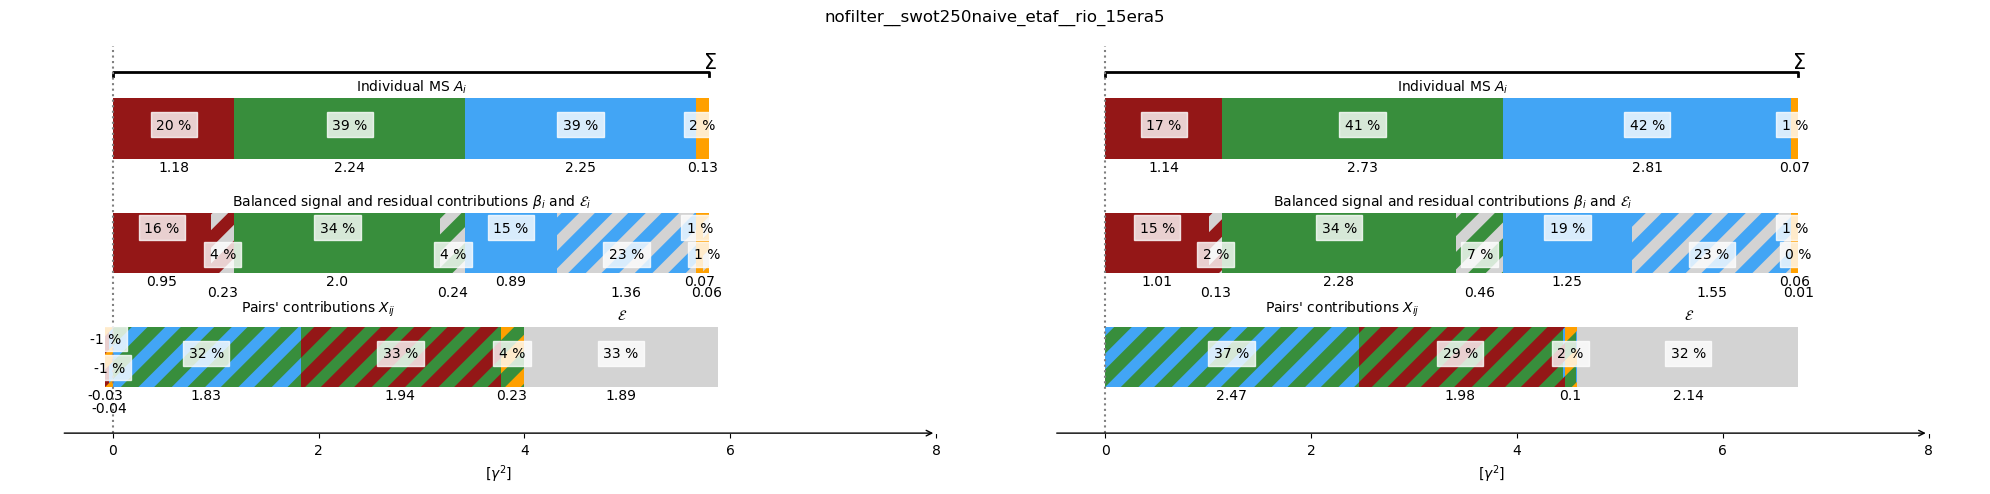

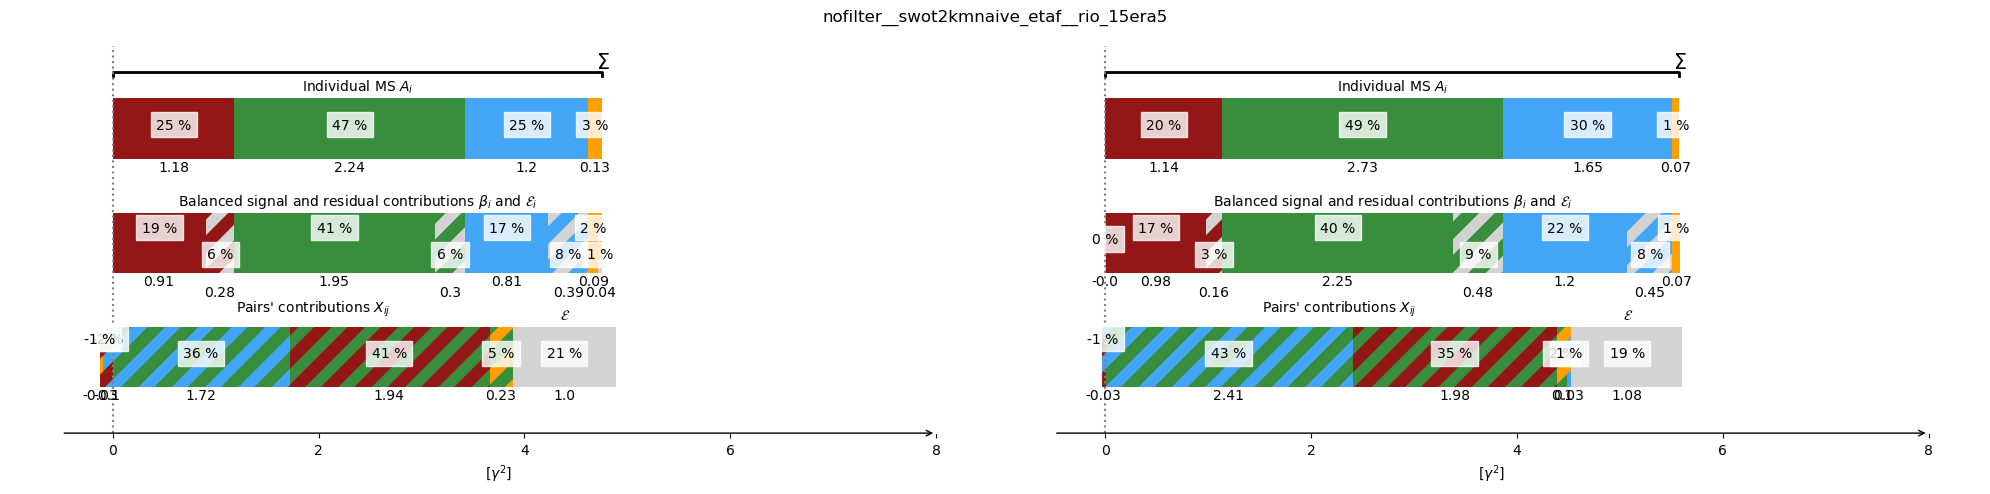

In [7]:
ds = compute_mean_square(DSD)/U2
df = ds.to_dataframe()
print(DSD.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

__________________
## Sensitivity to SWOT-250m filtering

nofilter__swot250naive_etaf__rio_0era5
nofilter__swot250gauss1e3_etaf__rio_0era5
nofilter__swot250gauss2e3_etaf__rio_0era5
nofilter__swot250gauss3e3_etaf__rio_0era5
nofilter__swot250gauss4e3_etaf__rio_0era5
nofilter__swot250gauss5e3_etaf__rio_0era5
8.937494478025732
9.234791513646963
9.341113499312081
9.463807451453446
8.49584708743648
8.78915180978841
8.817104751464184
8.935457237421925
8.029595170496004
8.314690078773843
8.301503528236776
8.424850670329839
7.647569912657124
7.920123310934179
7.913654571002998
8.045128187402224
7.371445436128008
7.6312072698030065
7.642927750270829
7.782135083346894
7.170183742396347
7.418207481716417
7.445525530571183
7.588054609263029


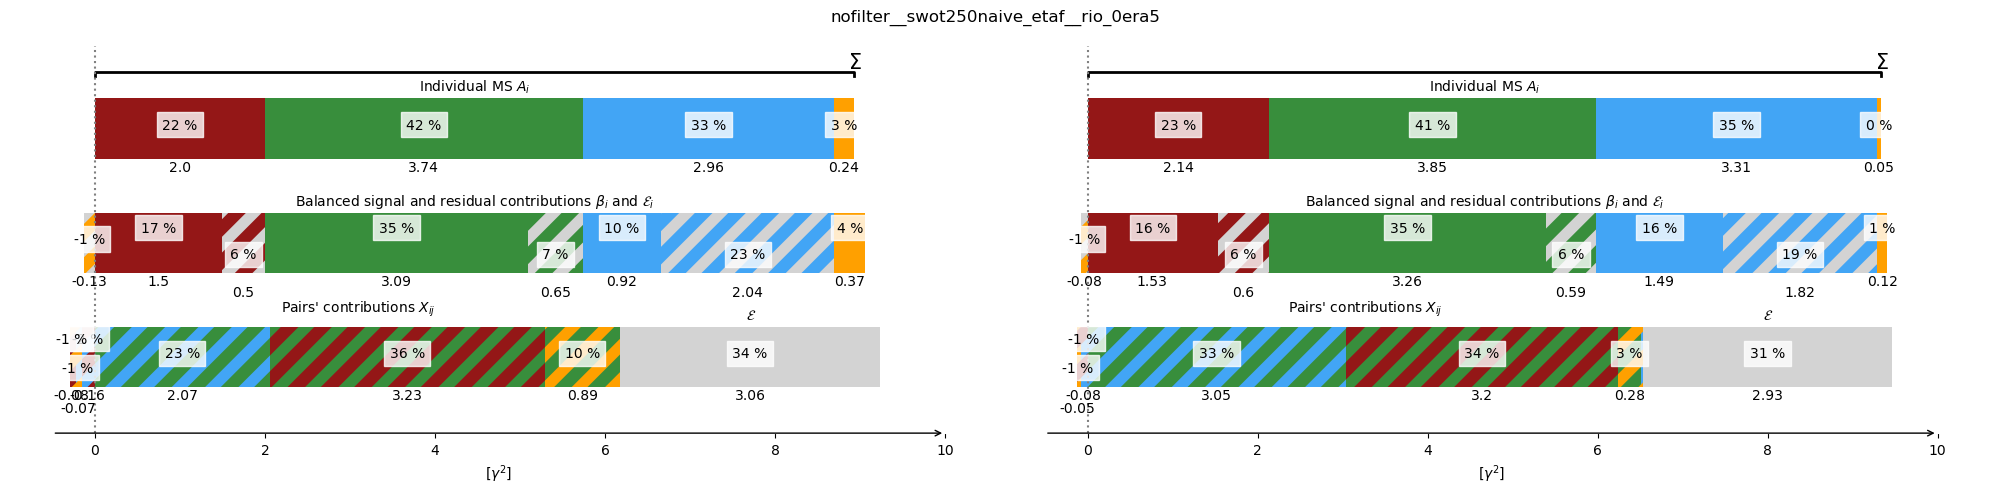

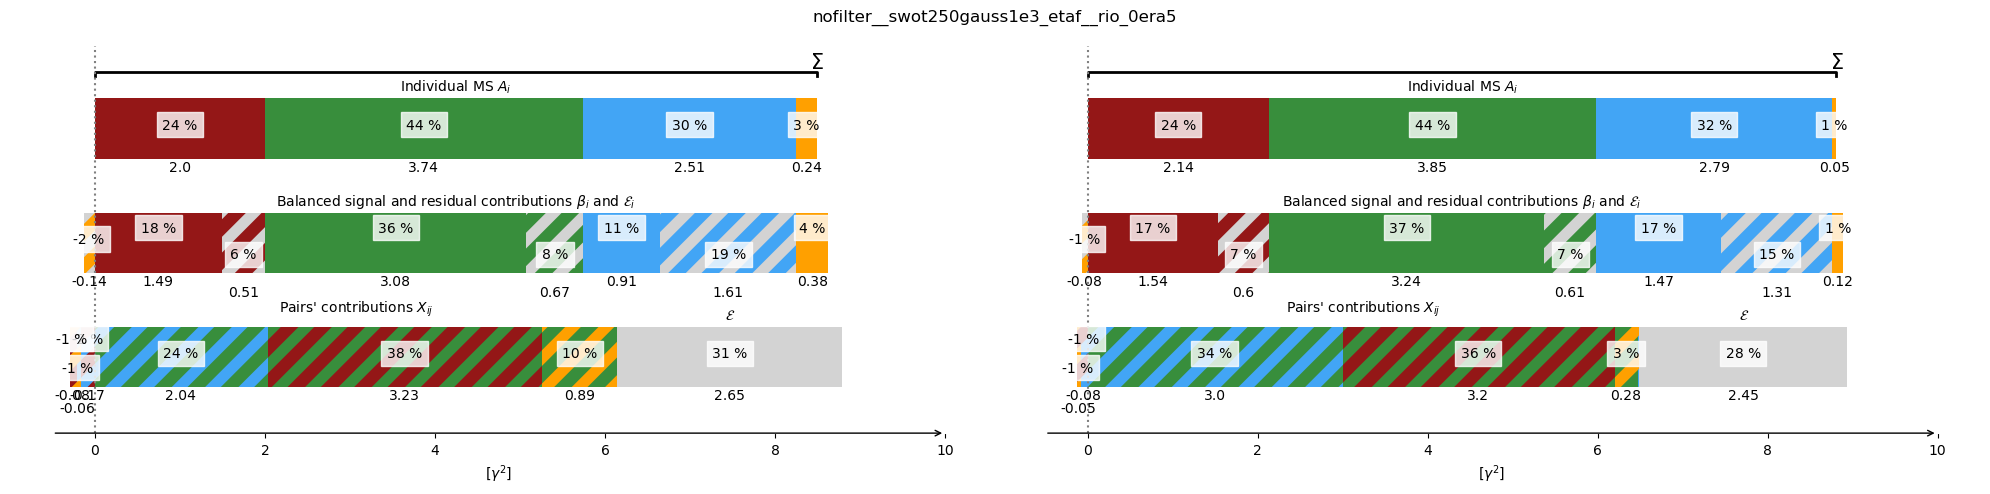

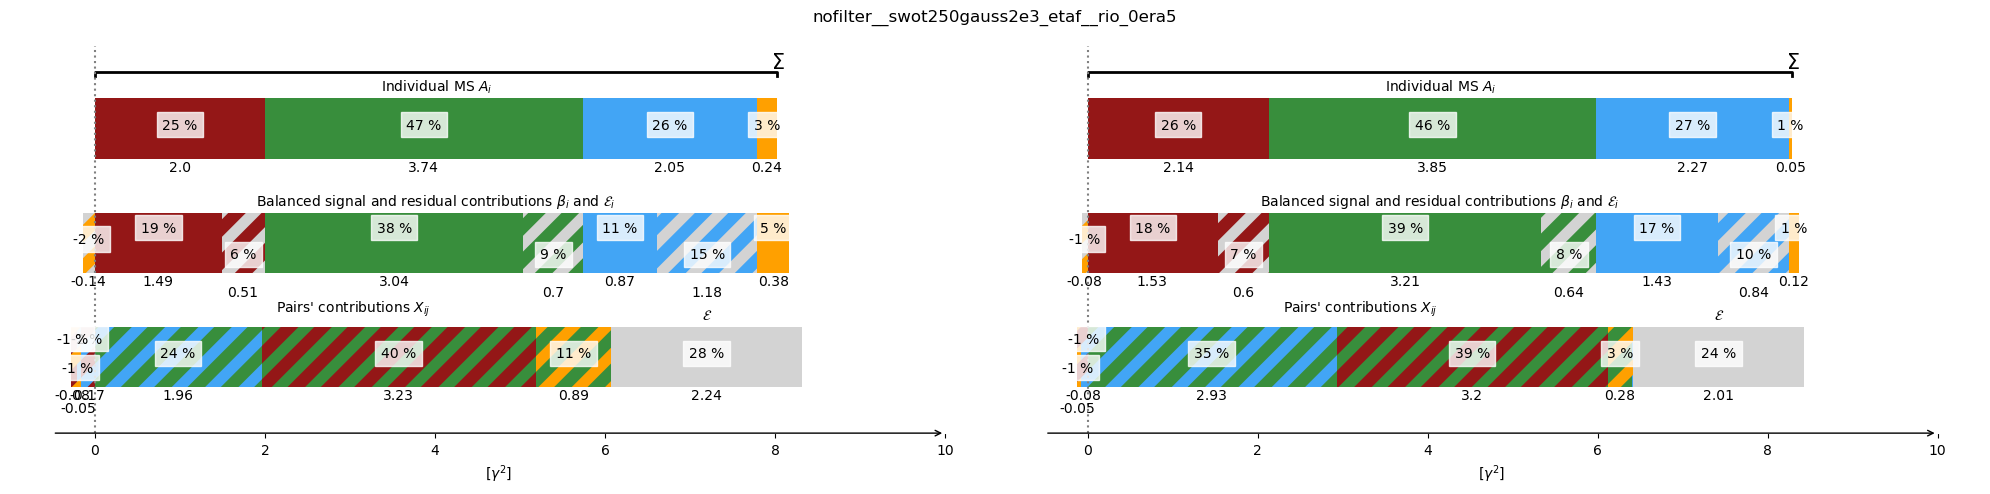

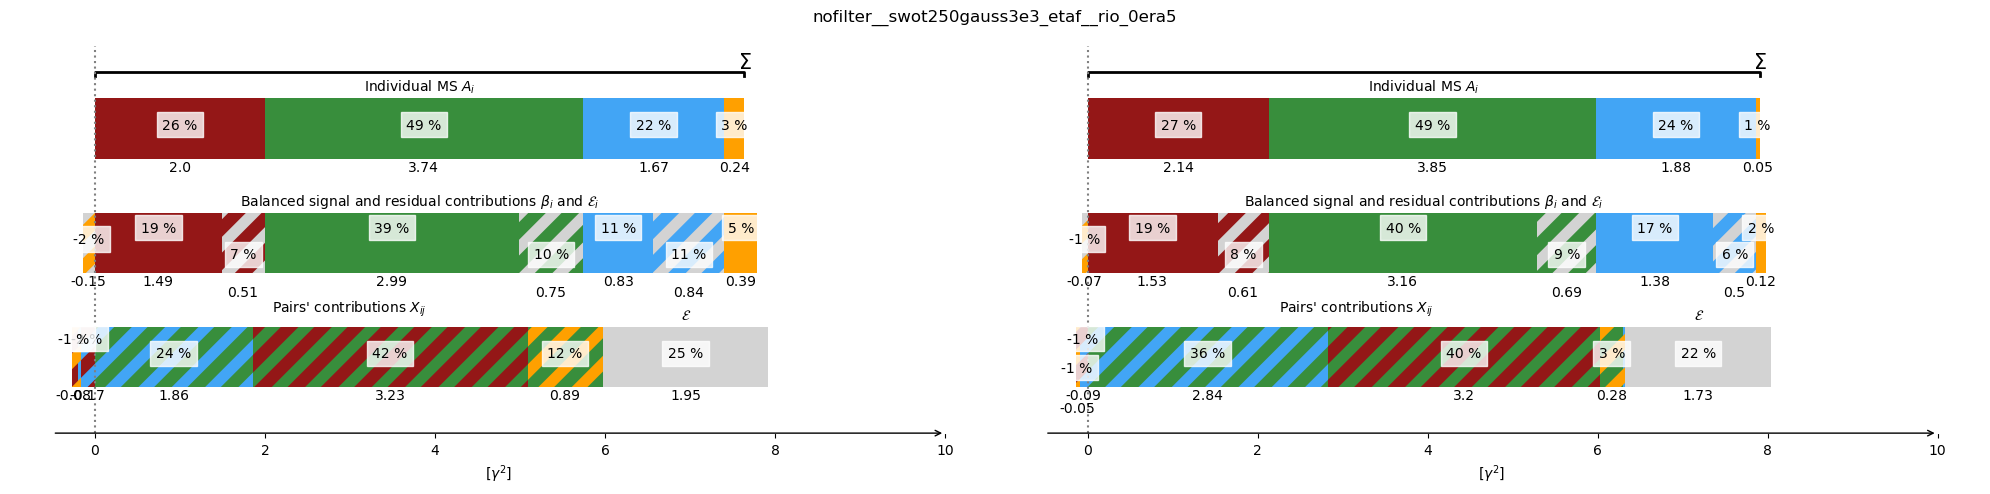

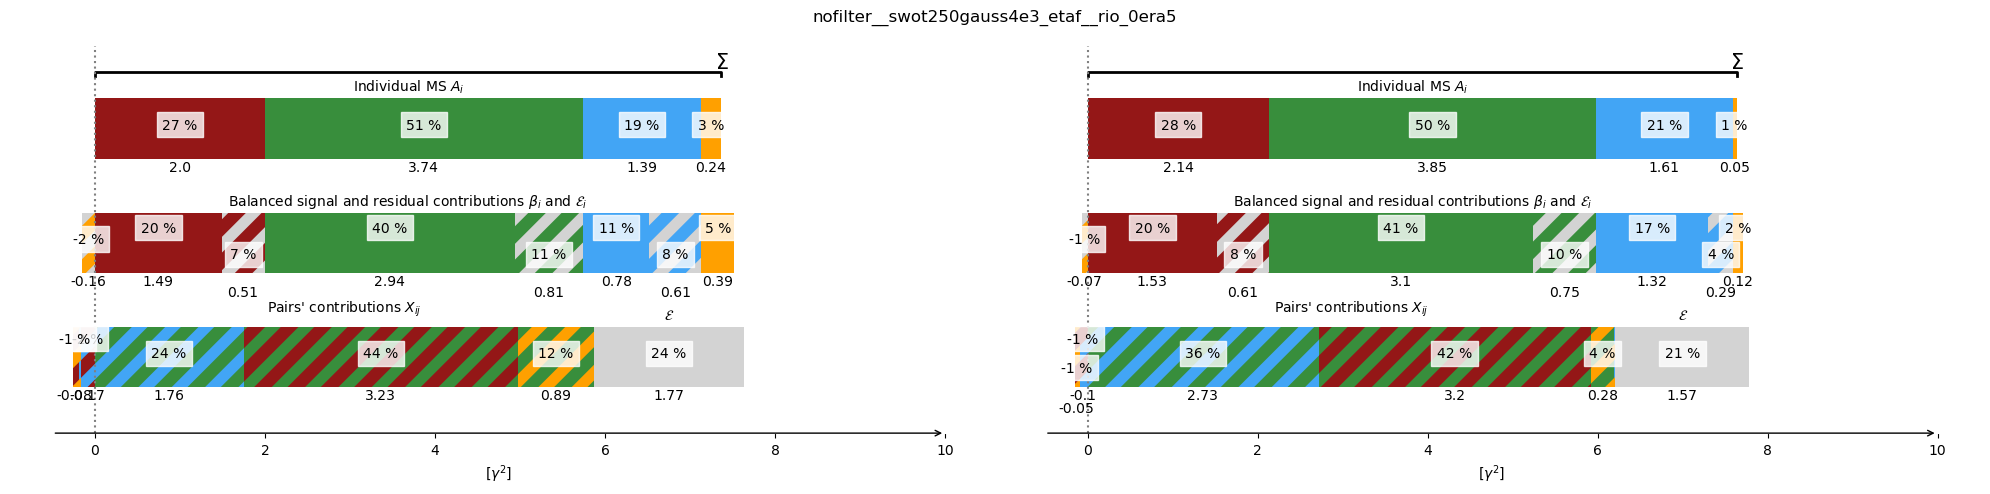

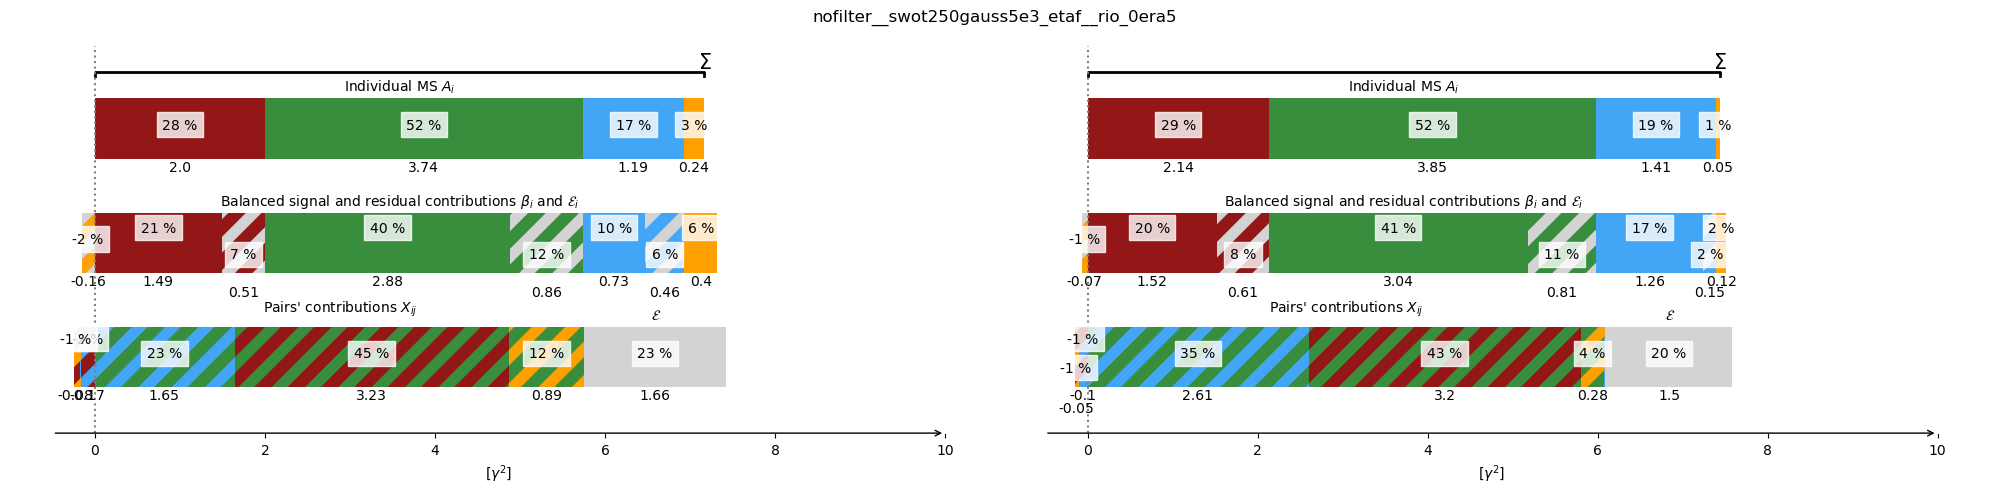

In [18]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False).dropna('row_number')
a = 3e-4
DS = DS.where((abs(DS.ggde)<a) & (abs(DS.ggdn)<a), drop=True) #delete ggd outliers
DSS = DS.where(DS.depth==0, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

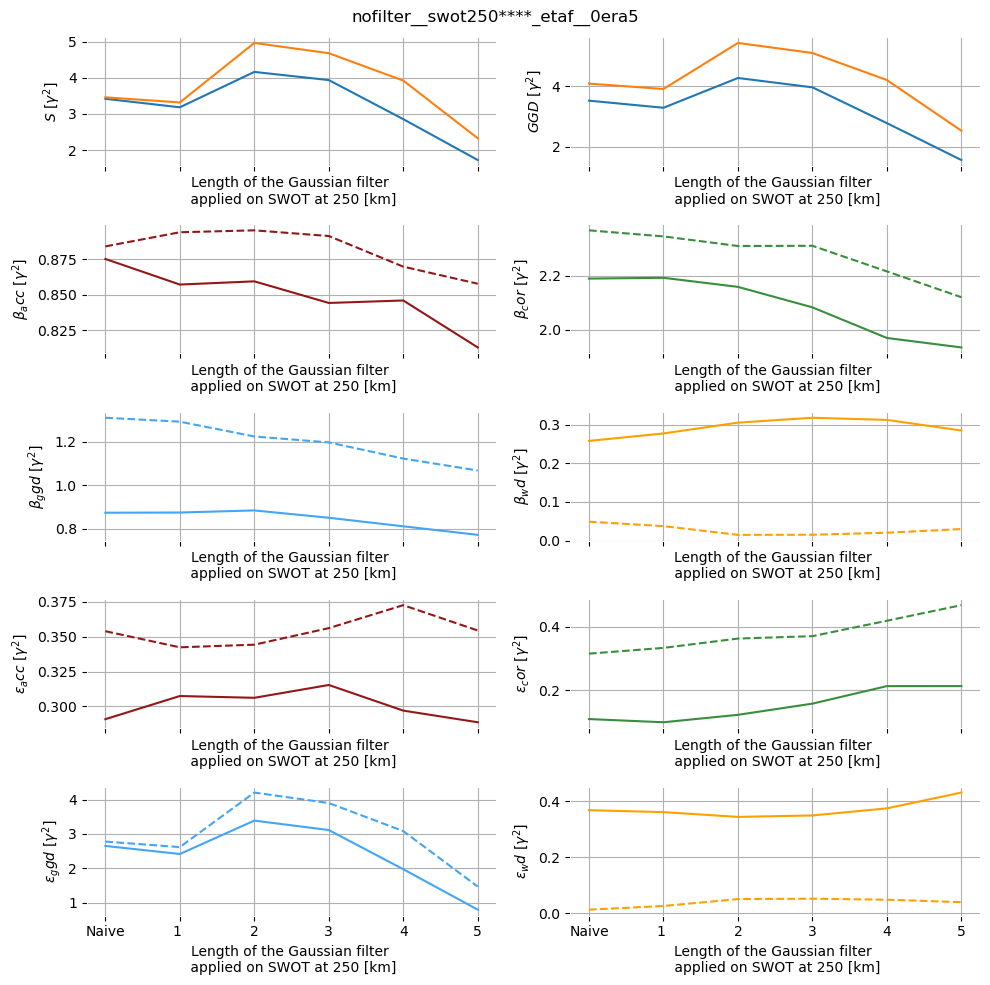

In [5]:
var= ['acc', 'cor', 'ggd', 'wd']
ds['id_comb']= ['Naive', '1 ', '2', '3', '4', '5']

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.GGDe.plot(ax=ax)
ds.GGDn.plot(ax=ax)
ax.set_ylabel(rf'$GGD$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Length of the Gaussian filter \n applied on SWOT at 250 [km]')
    ax.grid()
fig.suptitle('nofilter__swot250****_etaf__0era5')
fig.tight_layout()

In [6]:
ds

<xarray.Dataset> Size: 2kB
Dimensions:     (id_comb: 6)
Coordinates:
  * id_comb     (id_comb) <U5 120B 'Naive' '1 ' '2' '3' '4' '5'
Data variables: (12/41)
    ACCn        (id_comb) float64 48B 1.122 1.145 1.14 1.156 1.198 1.205
    CORn        (id_comb) float64 48B 2.954 2.97 2.978 3.044 3.225 3.369
    GGDn        (id_comb) float64 48B 110.3 57.36 15.02 7.065 4.034 2.779
    WDn         (id_comb) float64 48B 0.004063 0.004265 ... 0.004707 0.004984
    Sn          (id_comb) float64 48B 109.5 56.6 14.31 6.444 3.524 2.232
    ACCe        (id_comb) float64 48B 1.132 1.127 1.121 1.164 1.147 1.166
    ...          ...
    Xn_acc_cor  (id_comb) float64 48B 1.991 2.131 2.099 2.131 2.243 2.416
    Xn_acc_ggd  (id_comb) float64 48B -0.2157 -0.1701 ... -0.3773 -0.3912
    Xn_acc_wd   (id_comb) float64 48B -0.008133 -0.008084 ... -0.008751
    Xn_cor_ggd  (id_comb) float64 48B 3.065 2.904 2.909 2.88 3.032 3.064
    Xn_cor_wd   (id_comb) float64 48B 0.03382 0.03408 ... 0.03804 0.04655
    Xn_ggd_wd   (id_comb) float64 48B -0.03095 -0.01528 ... 0.006423 -0.000745

______
# Sensitivity of SWOT 250m 2e3 to the drifter filter

nofilter__swot250gauss2e3_etaf__rio_0era5
0.5cpd__swot250gauss2e3_etaf__rio_0era5
1.5cpd__swot250gauss2e3_etaf__rio_0era5
2.5cpd__swot250gauss2e3_etaf__rio_0era5
3cpd__swot250gauss2e3_etaf__rio_0era5
10.469307603939153
10.921079217779265
19.20159519152587
19.6732364556948
8.460066715593825
8.726904338552252
16.890925120677622
17.19110657847488
9.85375520472847
10.360458735889857
18.44310925613379
18.92485283403744
10.13879816466002
10.645896976674015
18.990823912684984
19.566882795967533
10.223204418598922
10.7550308133016
19.10226454878441
19.65056575968077


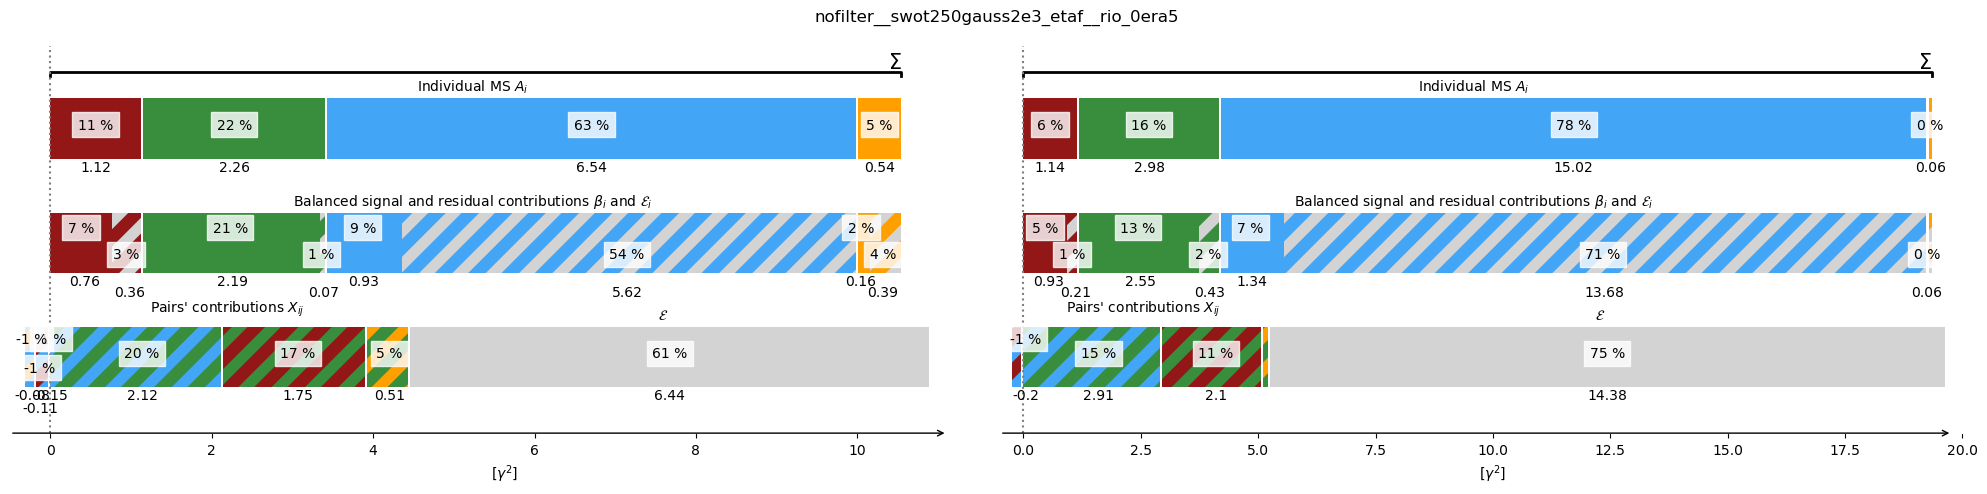

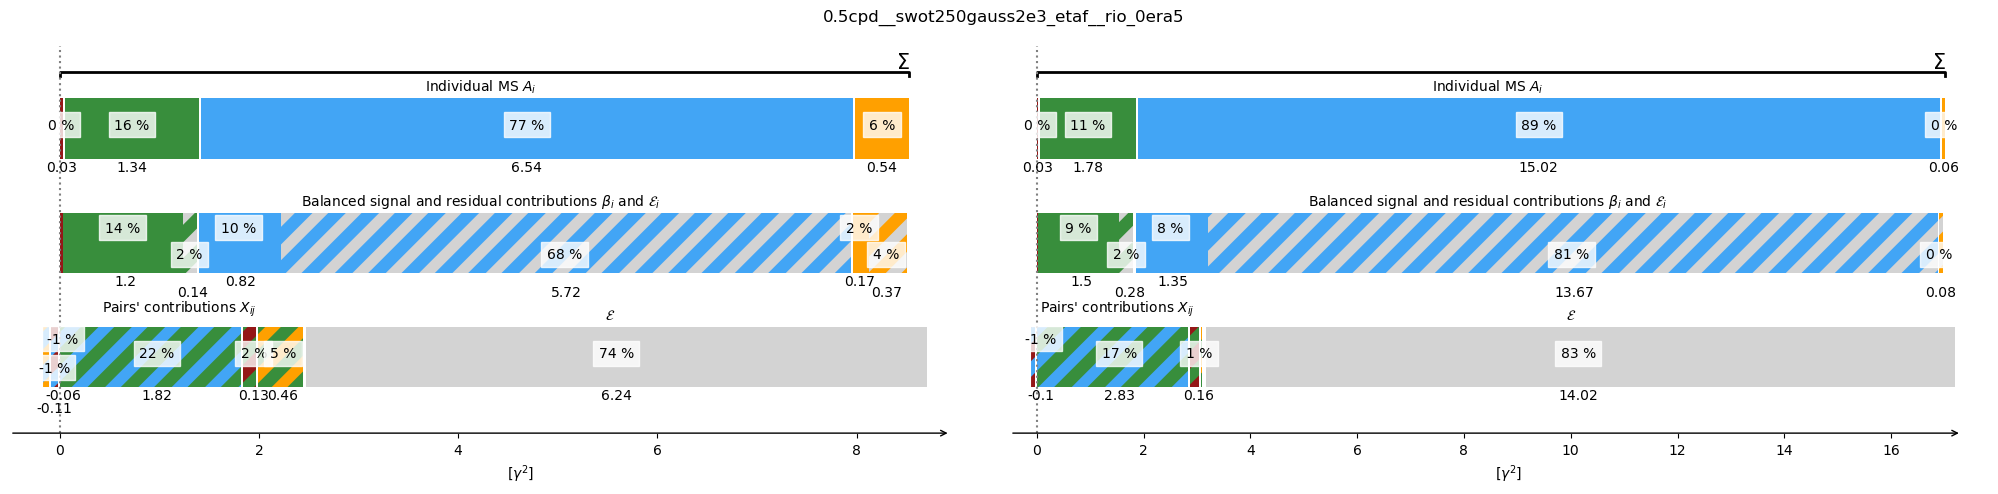

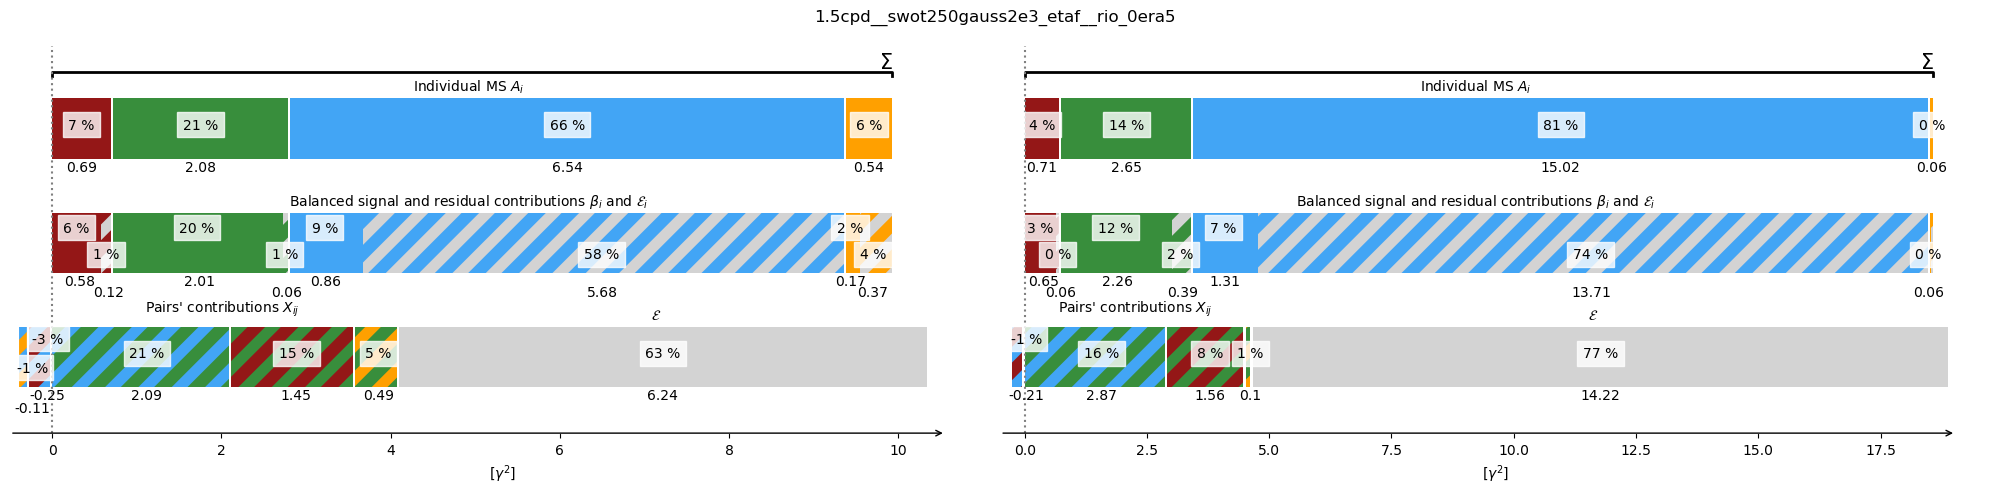

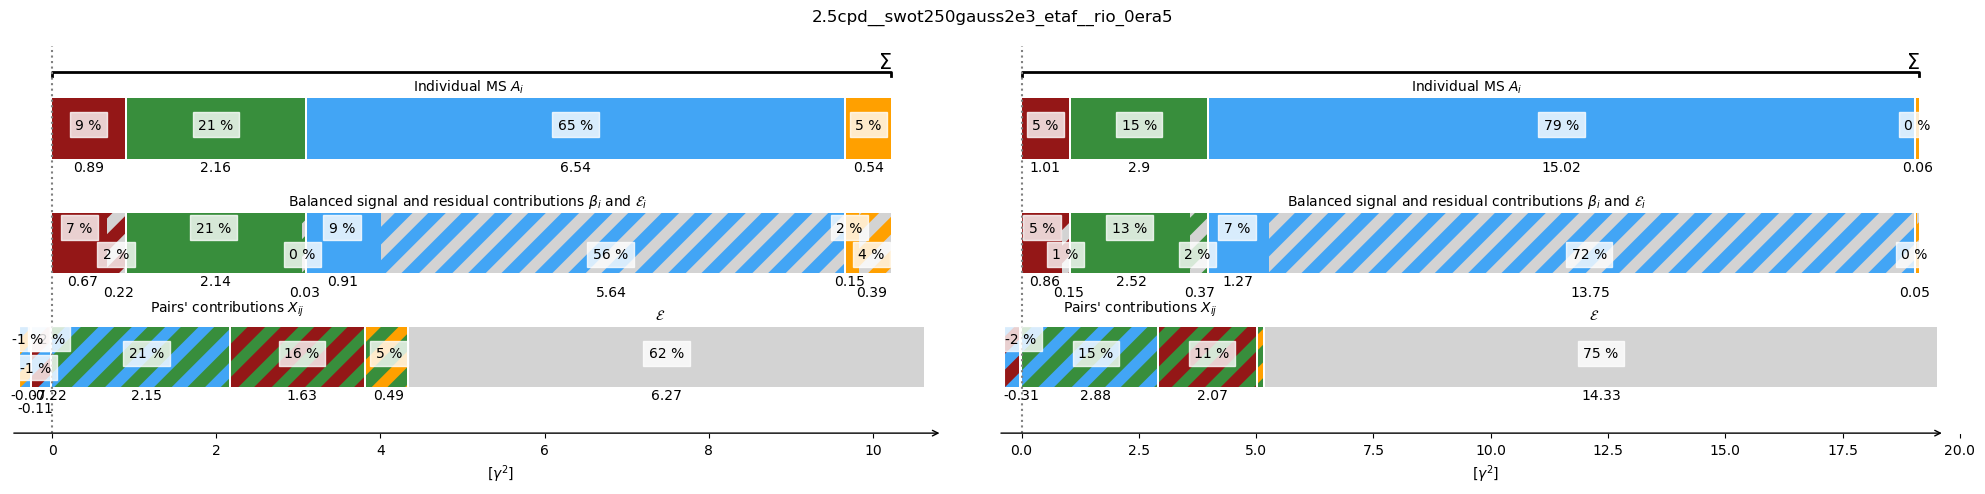

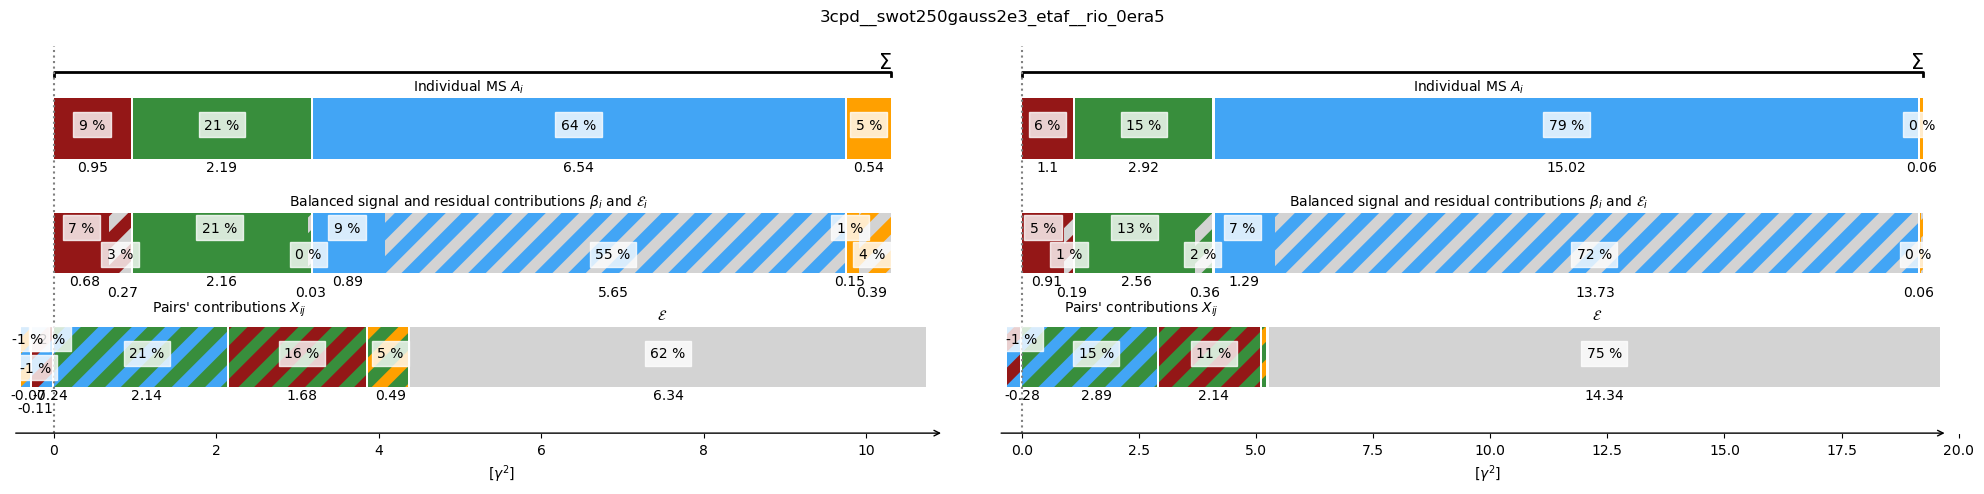

In [6]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='0.5cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='1.5cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='2.5cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='3cpd', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             ]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()

In [114]:
DS.ggde.var('row_number')/U2

<xarray.DataArray 'ggde' (id_comb: 6)> Size: 48B
array([12.00827648,  5.68351449,  4.17799982,  3.07795608,  1.90902055,
        1.38092692])
Coordinates:
  * id_comb  (id_comb) <U38 912B 'nofilter__swot250naive_etaf__15era5' ... 'n...

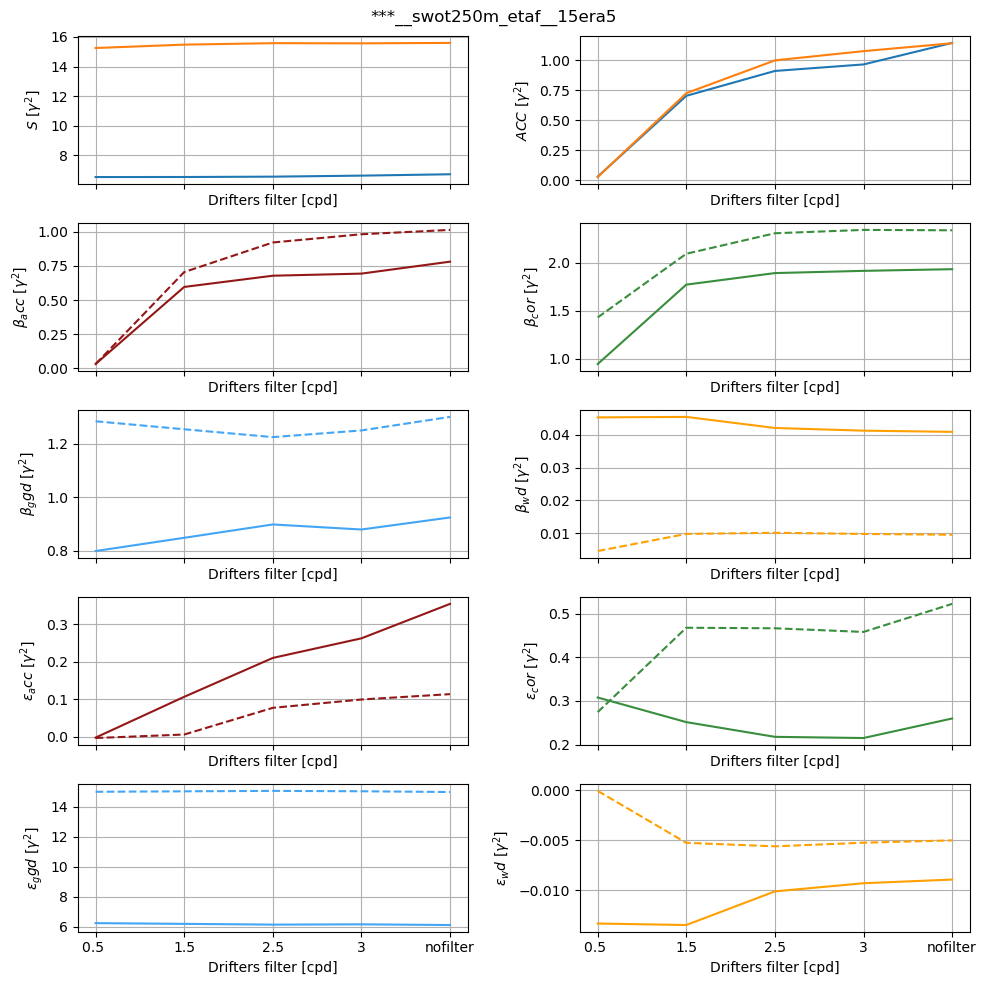

In [85]:
var= ['acc', 'cor', 'ggd', 'wd']
if not 'nofilter' in ds.id_comb :
    ds['id_comb']= ['nofilter', '0.5 ', '1.5', '2.5', '3']
    ds = ds.sortby('id_comb', ['0.5 ', '1.5', '2.5', '3', 'no_filter'])

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.ACCe.plot(ax=ax)
ds.ACCn.plot(ax=ax)
ax.set_ylabel(rf'$ACC$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Drifters filter [cpd]')
    ax.grid()
fig.suptitle('***__swot250m_etaf__15era5')
fig.tight_layout()

________________
# SWOT 2km filter on alti ?

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmgauss1e3_etaf__rio_0era5
nofilter__swot250naive_etaf__rio_0era5
7.539047374624893
7.945932706430634
7.786037780474858
8.000853909161842
7.132249475233202
7.472313776059699
7.350602251121012
7.550166190898047
9.607368434893683
10.098087432762842
10.14246343904676
10.36205828879513


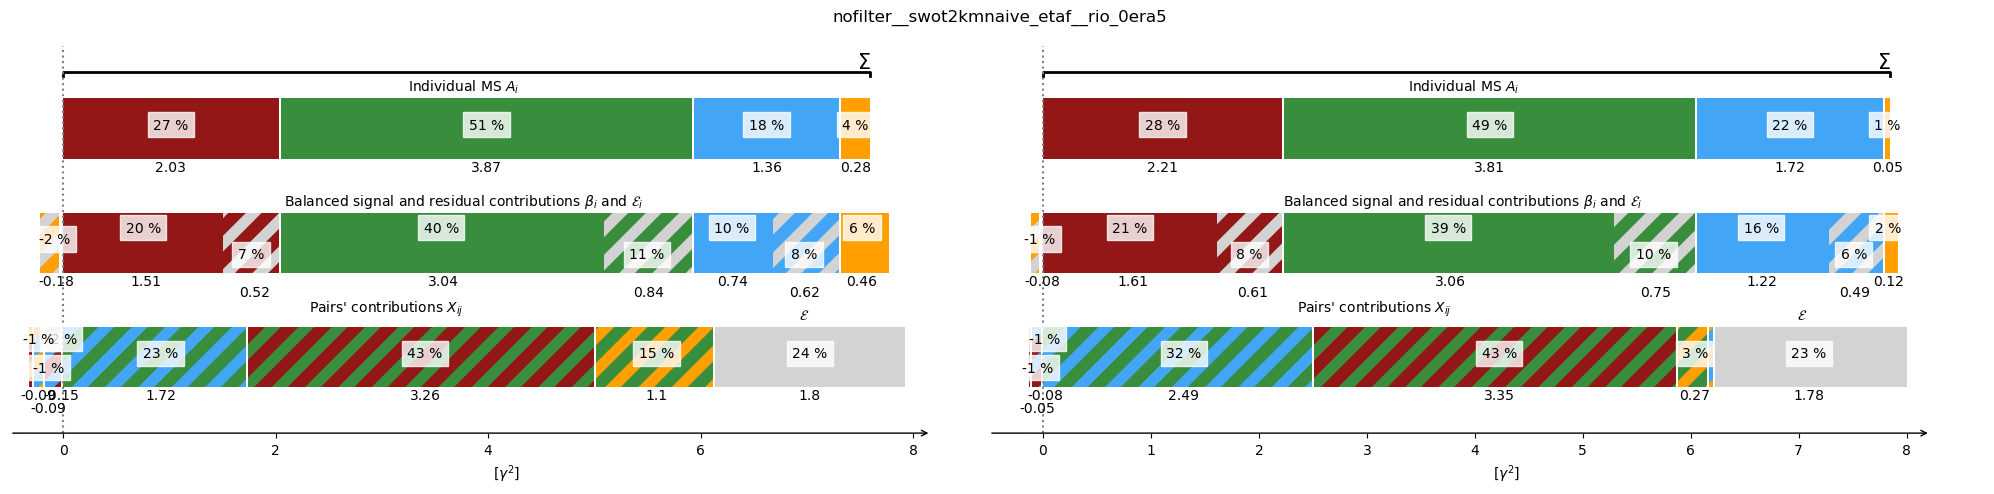

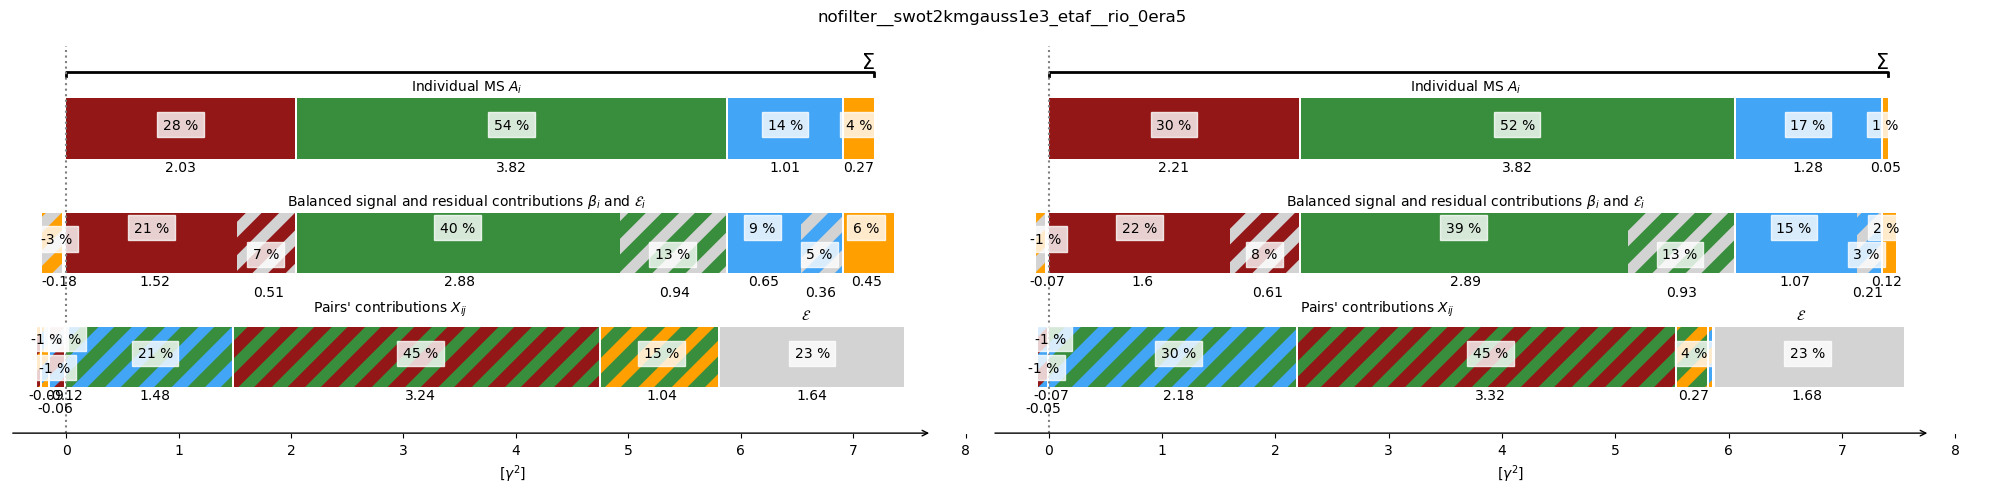

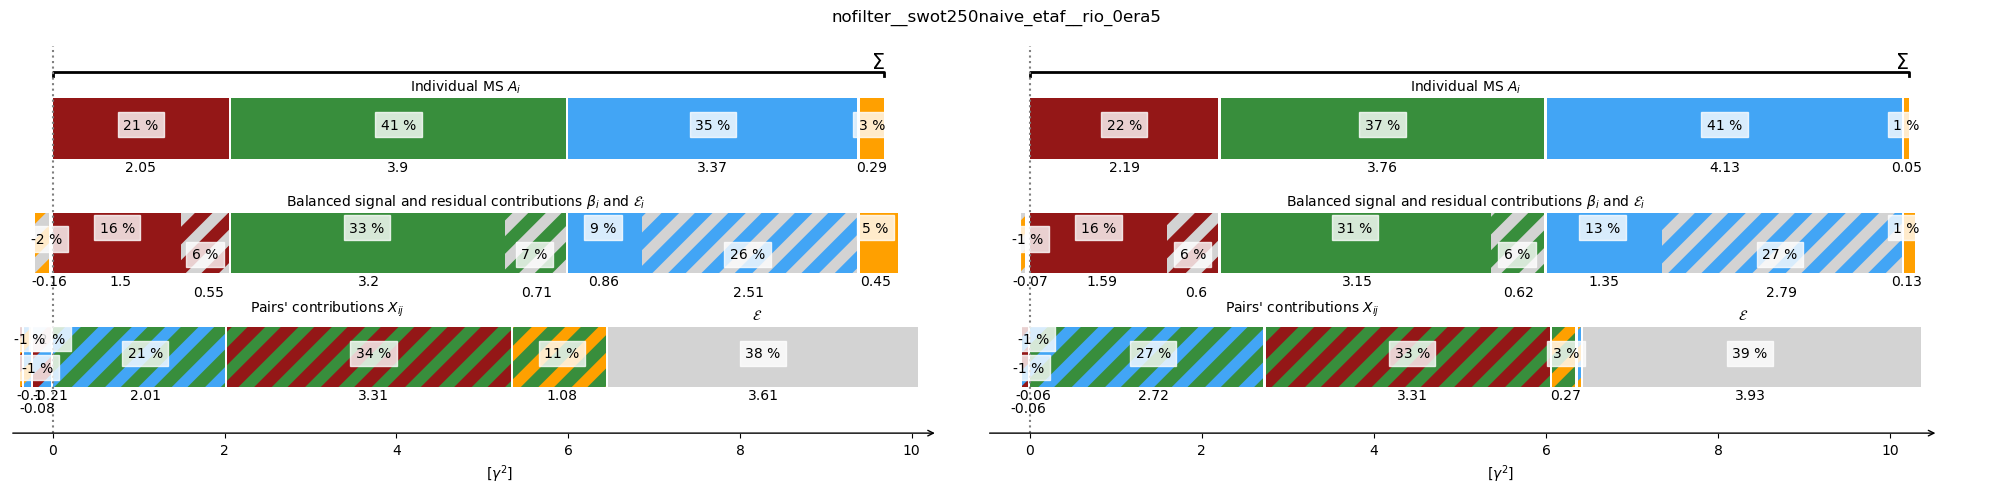

In [11]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot2kmgauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             #dict(drifter_key='nofilter', alti_key = 'swot2kmgauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             #dict(drifter_key='nofilter', alti_key = 'swot2kmgauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             #dict(drifter_key='nofilter', alti_key = 'swot2kmgauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             #dict(drifter_key='nofilter', alti_key = 'swot2kmgauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSS)/U2

df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()

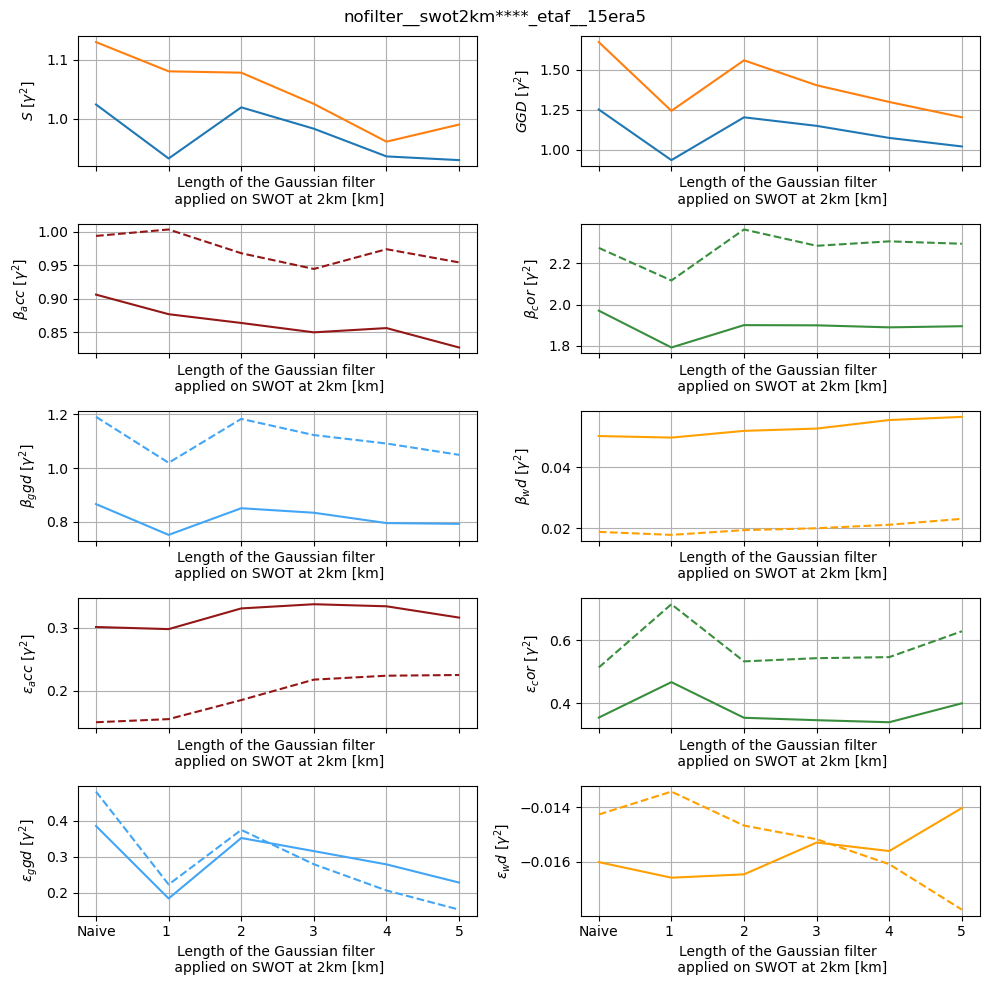

In [82]:
var= ['acc', 'cor', 'ggd', 'wd']
ds['id_comb']= ['Naive', '1 ', '2', '3', '4', '5']

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.GGDe.plot(ax=ax)
ds.GGDn.plot(ax=ax)
ax.set_ylabel(rf'$GGD$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Length of the Gaussian filter \n applied on SWOT at 2km [km]')
    ax.grid()
fig.suptitle('nofilter__swot2km****_etaf__15era5')
fig.tight_layout()

________________
# SWOT 2km filter on alti ?

nofilter__swot2kmnaive_etaf__15era5
0.5cpd__swot2kmnaive_etaf__15era5
1.5cpd__swot2kmnaive_etaf__15era5
2.5cpd__swot2kmnaive_etaf__15era5
3cpd__swot2kmnaive_etaf__15era5
4.703765021005737
4.723696715174654
5.802999586533861
5.654425985020742
2.638931893009576
2.619801405128777
3.479984993090941
3.313103821975629
4.074518480245626
4.06785156299007
5.1061859638469915
4.9669529500512875
4.397584362151594
4.4157439582370195
5.566658286742149
5.409780000591289
4.469341029616347
4.49206402610177
5.670734941655143
5.51575962108344


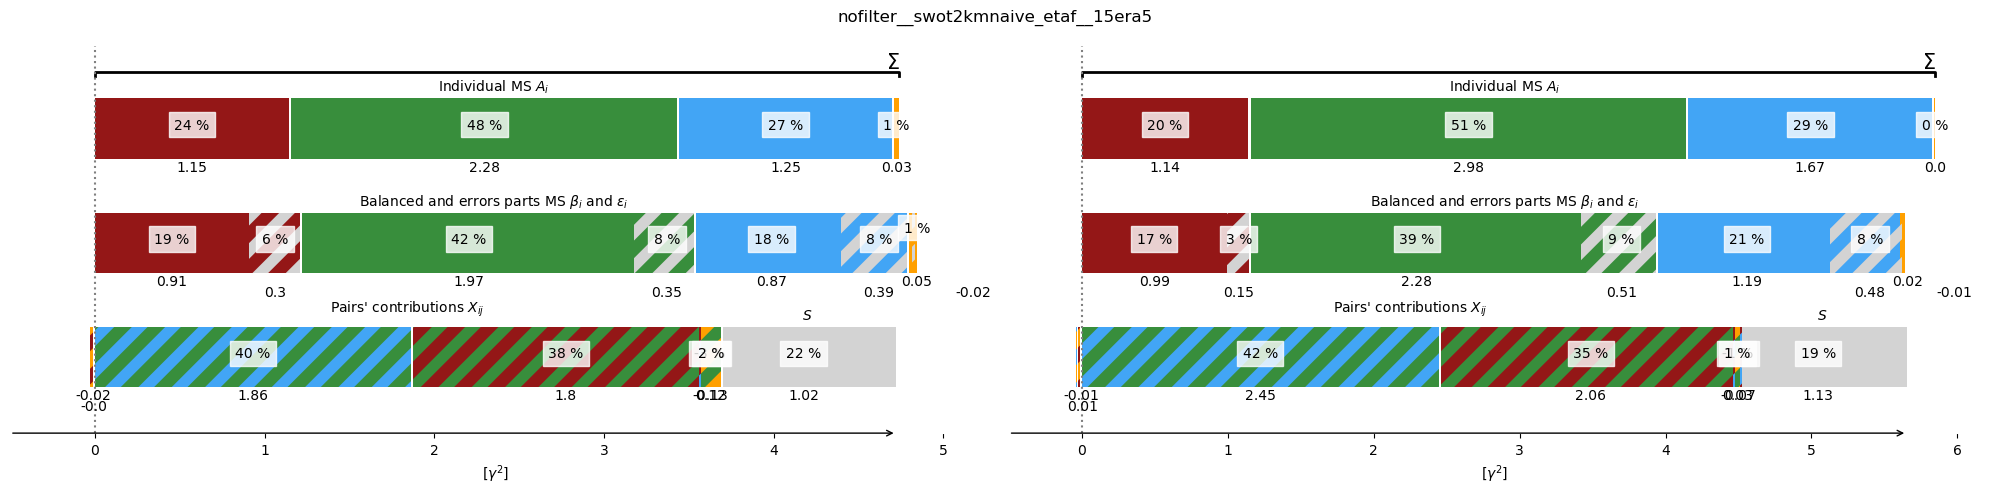

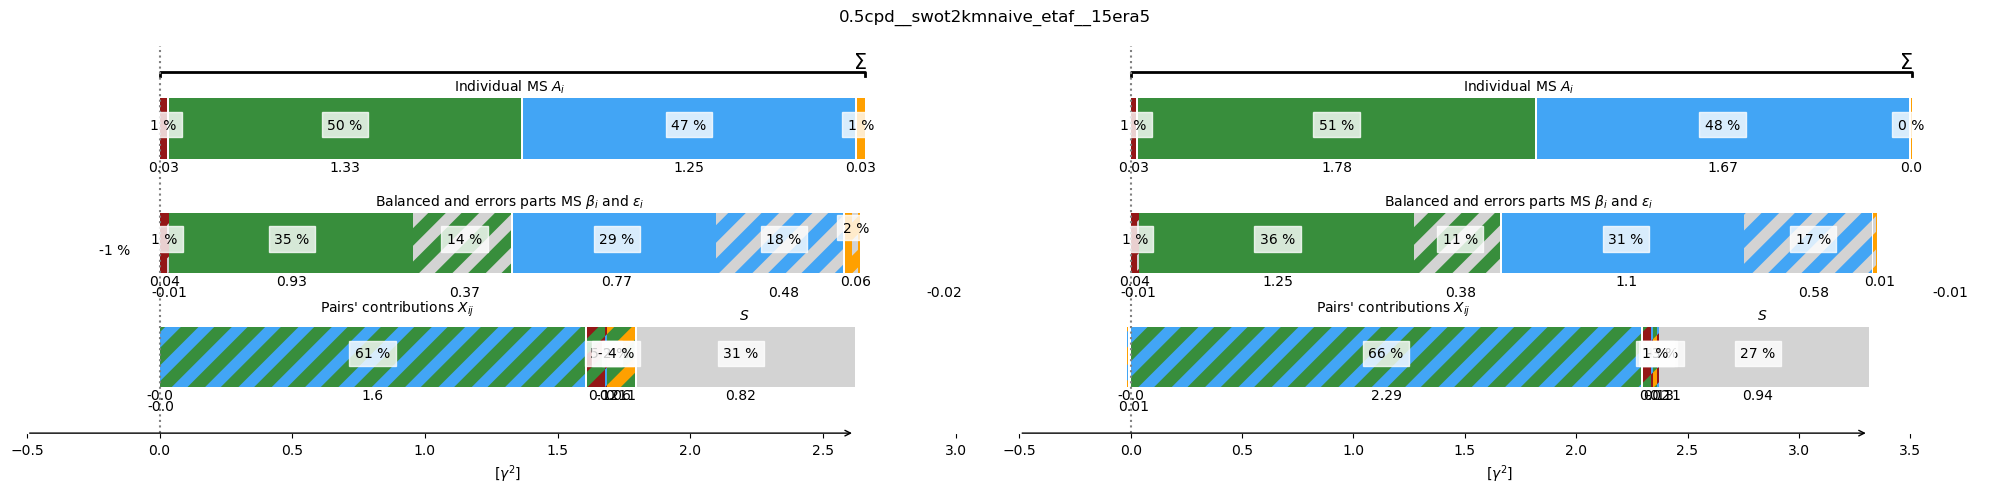

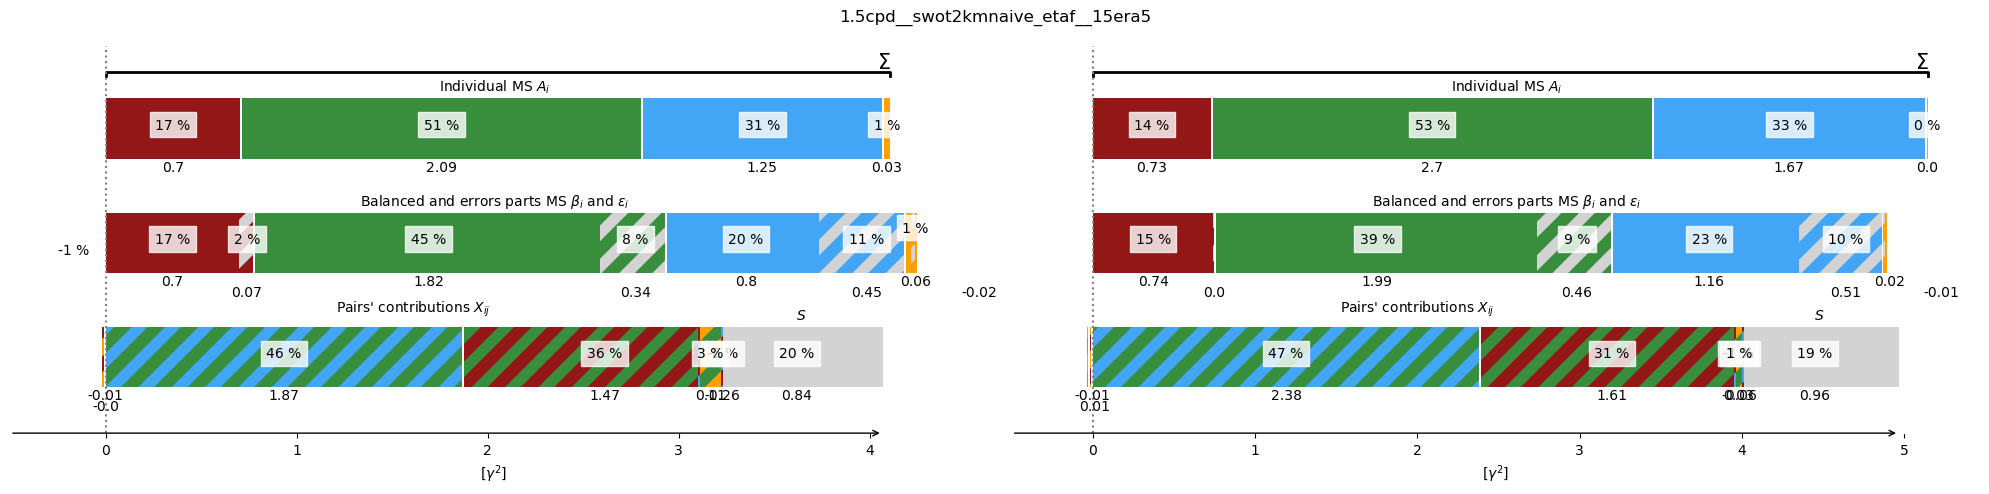

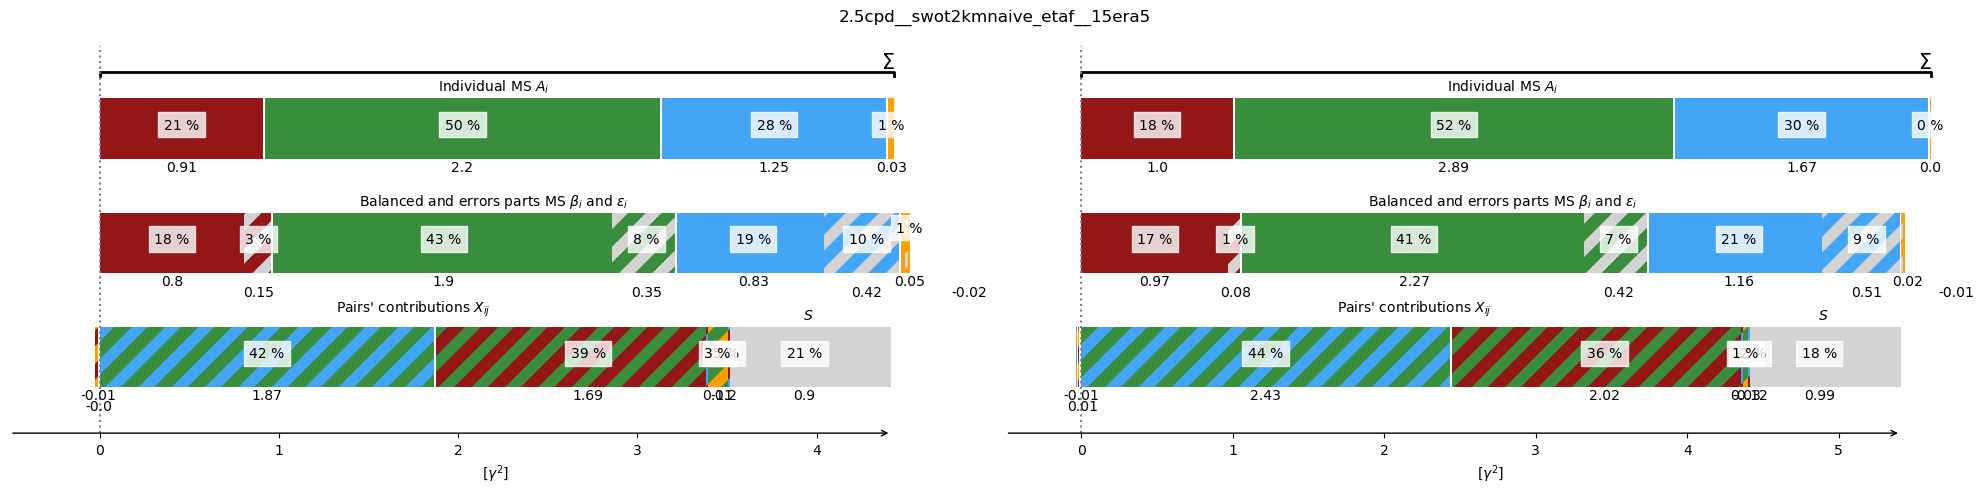

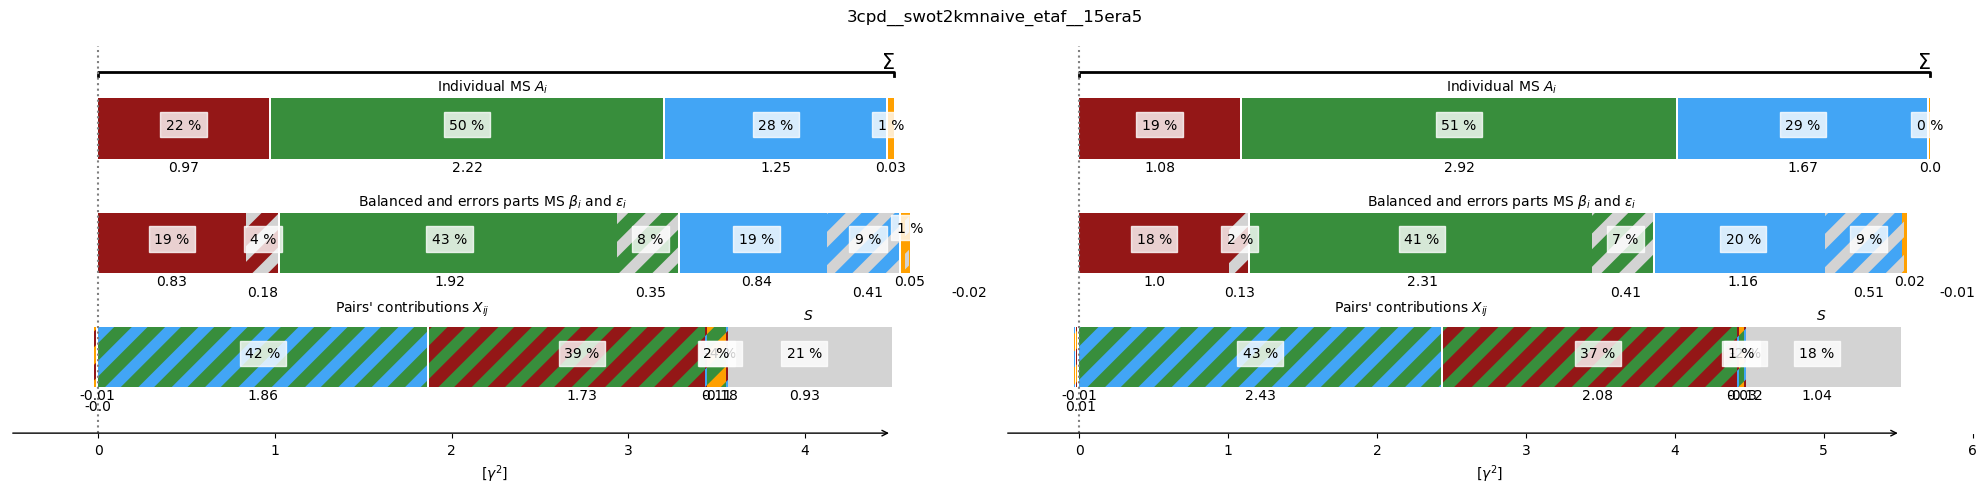

In [106]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='0.5cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='1.5cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='2.5cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='3cpd', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
             ]

DS = dataset_coloc_combs(comb_list, nearest =True)
DSS = DS.where(DS.depth==0, drop=True)
DSD = DS.where(DS.depth==15, drop=True)
ds = compute_mean_square(DSD)/U2

df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e')
    synthetic_figure(df.loc[c], axs[1], dir='n')
    fig.suptitle(c)
    fig.tight_layout()

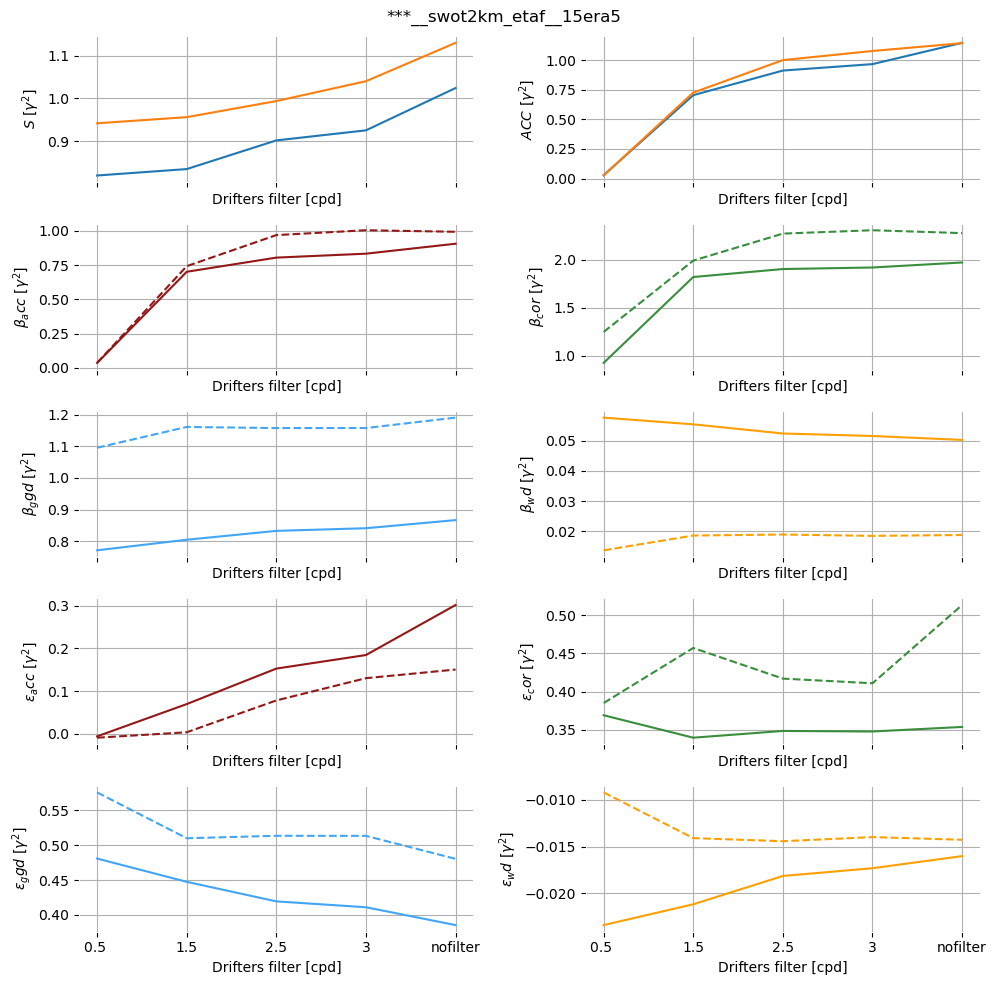

In [107]:
var= ['acc', 'cor', 'ggd', 'wd']
if not 'nofilter' in ds.id_comb :
    ds['id_comb']= ['nofilter', '0.5 ', '1.5', '2.5', '3']
    ds = ds.sortby('id_comb', ['0.5 ', '1.5', '2.5', '3', 'no_filter'])

fig, axs = plt.subplots(5,2, sharex=True, figsize = (10, 10))
axs =axs.flatten()

ax=axs[0]
ds.Se.plot(ax=ax)
ds.Sn.plot(ax=ax)
ax.set_ylabel(rf'$S$ [$\gamma^2$]')

ax=axs[1]
ds.ACCe.plot(ax=ax)
ds.ACCn.plot(ax=ax)
ax.set_ylabel(rf'$ACC$ [$\gamma^2$]')

for i in range(2, 6):
    v = var[i-2]
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, c=c0[v])
    ds['Bn_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\beta_{v}$ [$\gamma^2$]')

for i in range(6, 10):
    v = var[i-6]
    ax=axs[i]
    ds['Ee_'+v].plot(ax=ax, c=c0[v])
    ds['En_'+v].plot(ax=ax, c=c0[v], ls='--')
    ax.set_ylabel(rf'$\epsilon_{v}$ [$\gamma^2$]')
    
for ax in axs :
    ax.set_xlabel('Drifters filter [cpd]')
    ax.grid()
fig.suptitle('***__swot2km_etaf__15era5')
fig.tight_layout()

# Visualization

In [ ]:
ds__= DS.sel(id_comb = 'etaf_swot250gauss1e3__15era5').isel(row_number=slice(20,40))
fig, ax = plt.subplots()
s = 3e-4
ds__.plot.quiver('longitude', 'latitude', 'acce', 'accn', color =c0['acc'], pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'core', 'corn', color =c0['cor'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'ggde', 'ggdn', color =c0['ggd'],pivot='tail', scale=s )
ds__.plot.quiver('longitude', 'latitude', 'wde', 'wdn', color =c0['wd'],pivot='tail', scale=s)
ds__.plot.quiver('longitude', 'latitude', 'sume', 'sumn', color ='k', pivot='tail', scale=s )

# Old Swot filtrage

5.827464383027202
5.968887558142416
7.815631173954805
7.8968408696419905
5.585850209282852
5.719890646854031
7.370497780005536
7.445348371633019
5.585850209282852
5.719890646854031
7.370497780005536
7.445348371633019
4.633770664425903
4.73958974547408
6.202247339303583
6.2623602785133


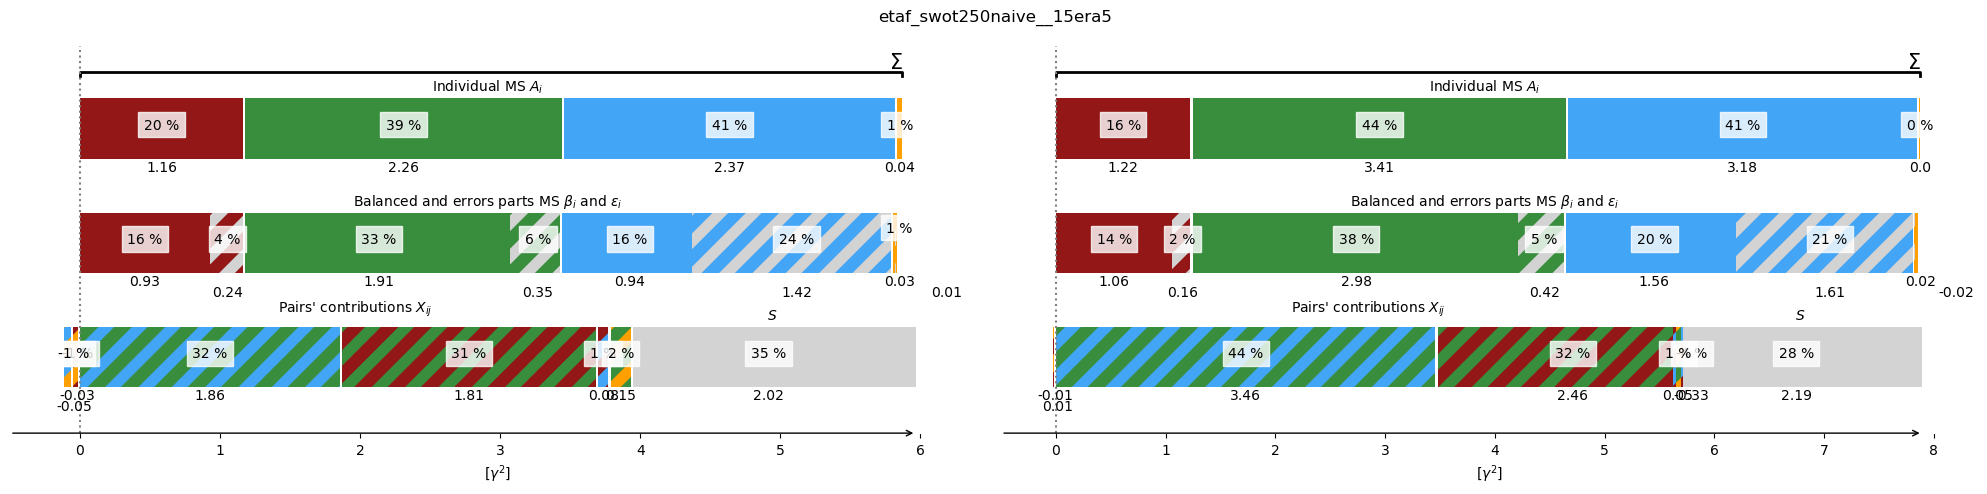

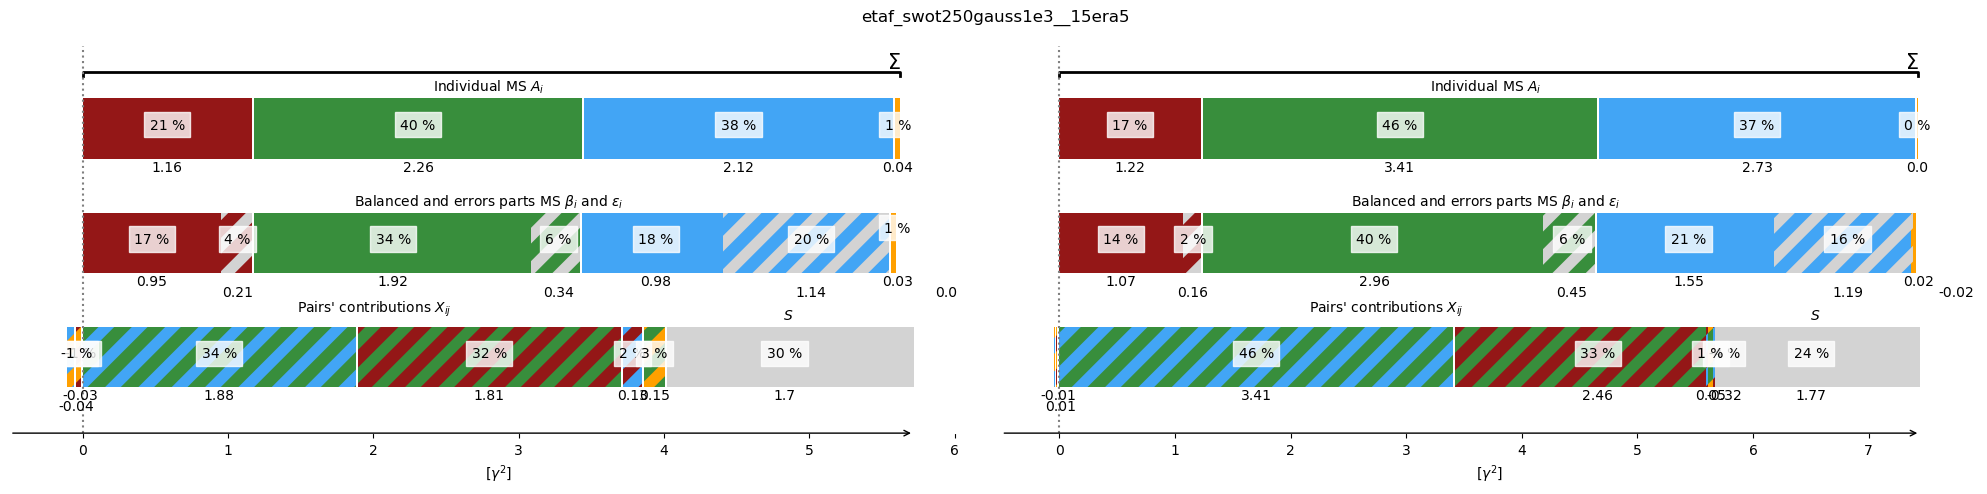

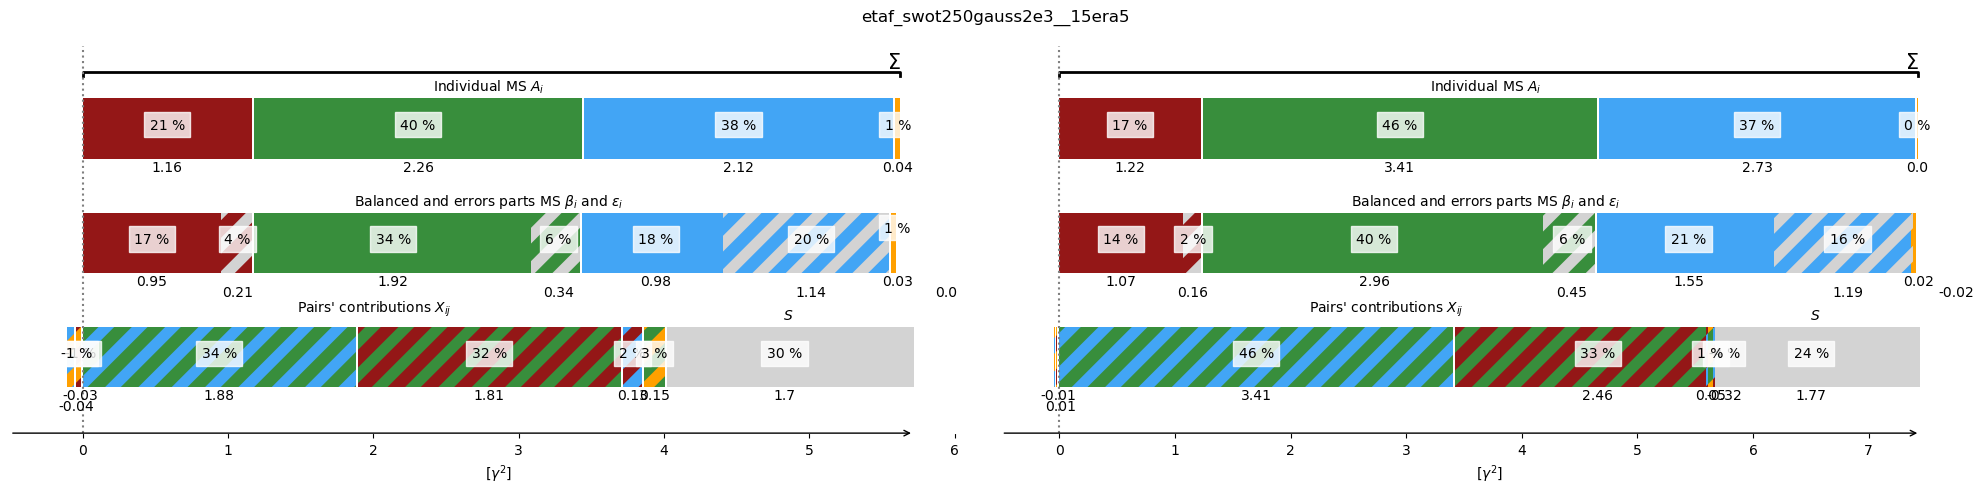

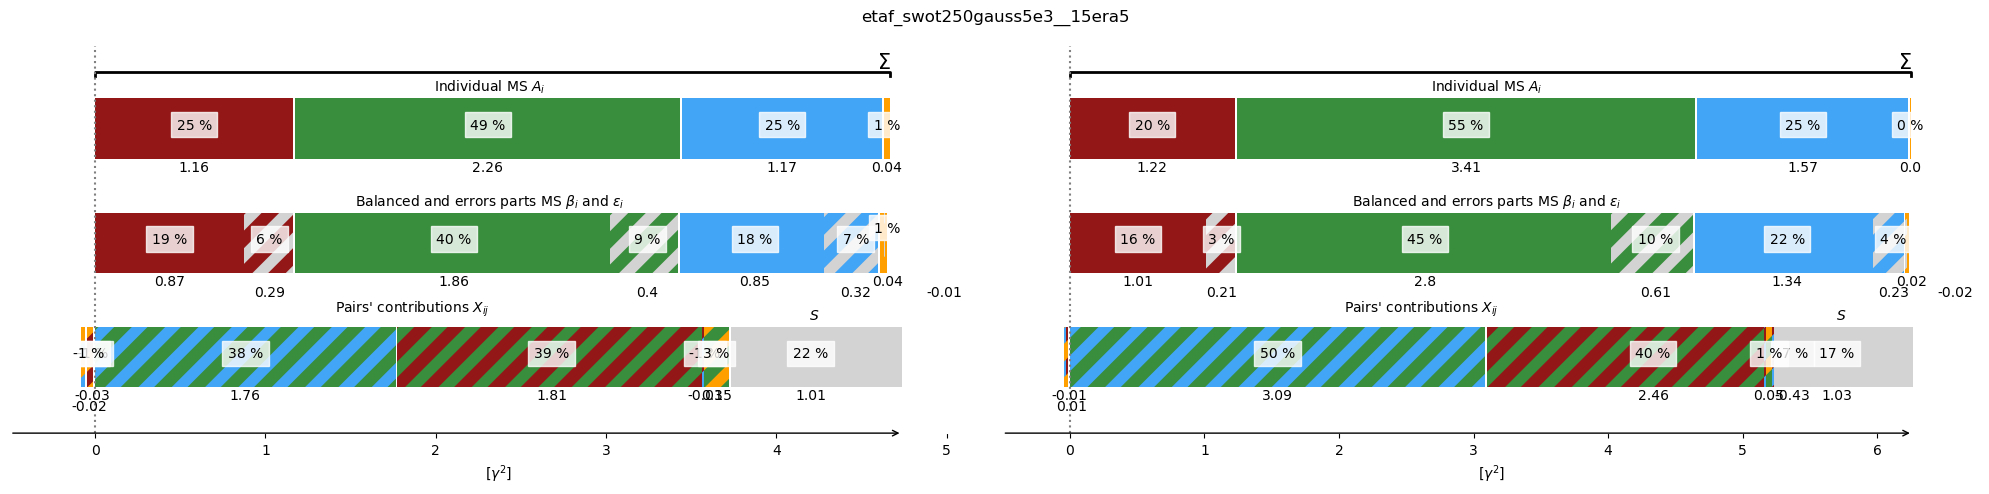

In [17]:
c = 'etaf_swot250naive__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etaf_swot250gauss1e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etaf_swot250gauss2e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etaf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

# Etaf, etac

4.633770664425903
4.73958974547408
6.202247339303583
6.2623602785133
4.661734564164215
4.761201244460434
6.2112122401862395
6.2708378004512415


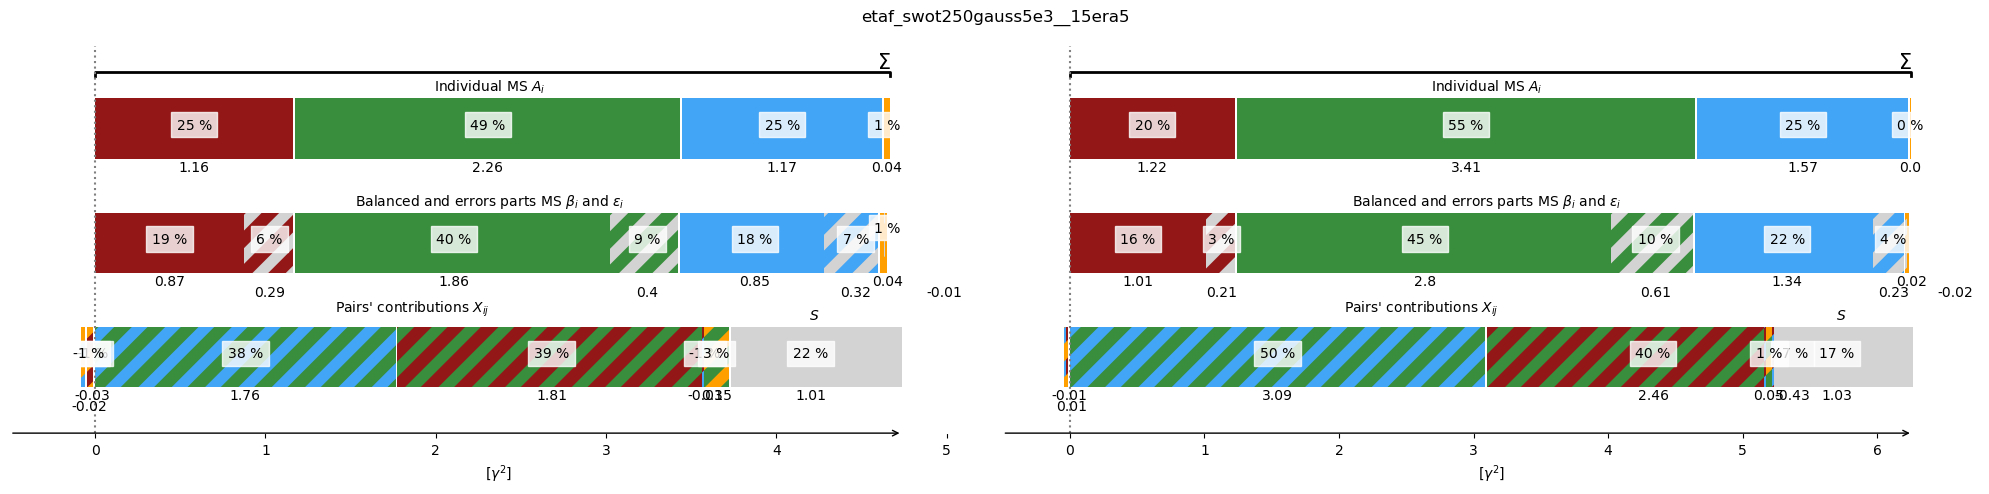

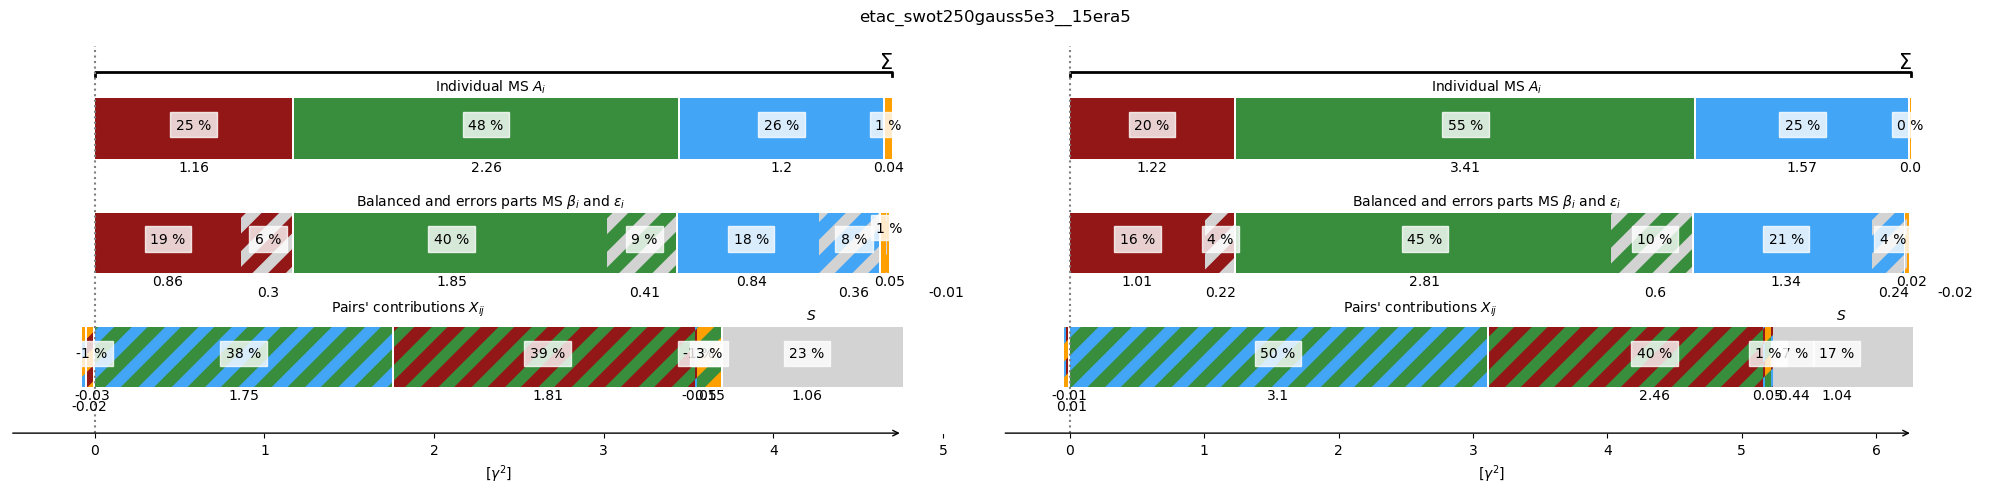

In [20]:
c = 'etaf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'etac_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

4.633770664425903
4.73958974547408
6.202247339303583
6.2623602785133
4.621676791866464
4.7244103926240335
6.203722741149835
6.263867718202855


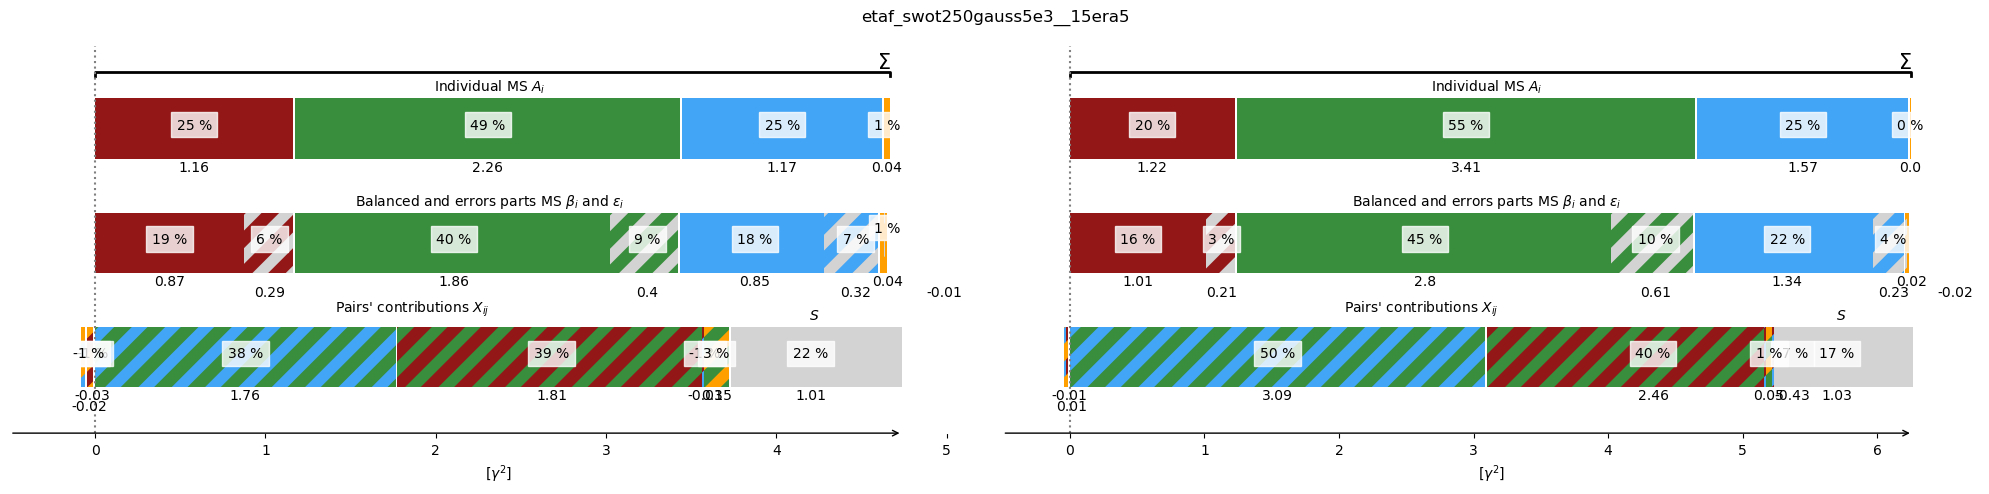

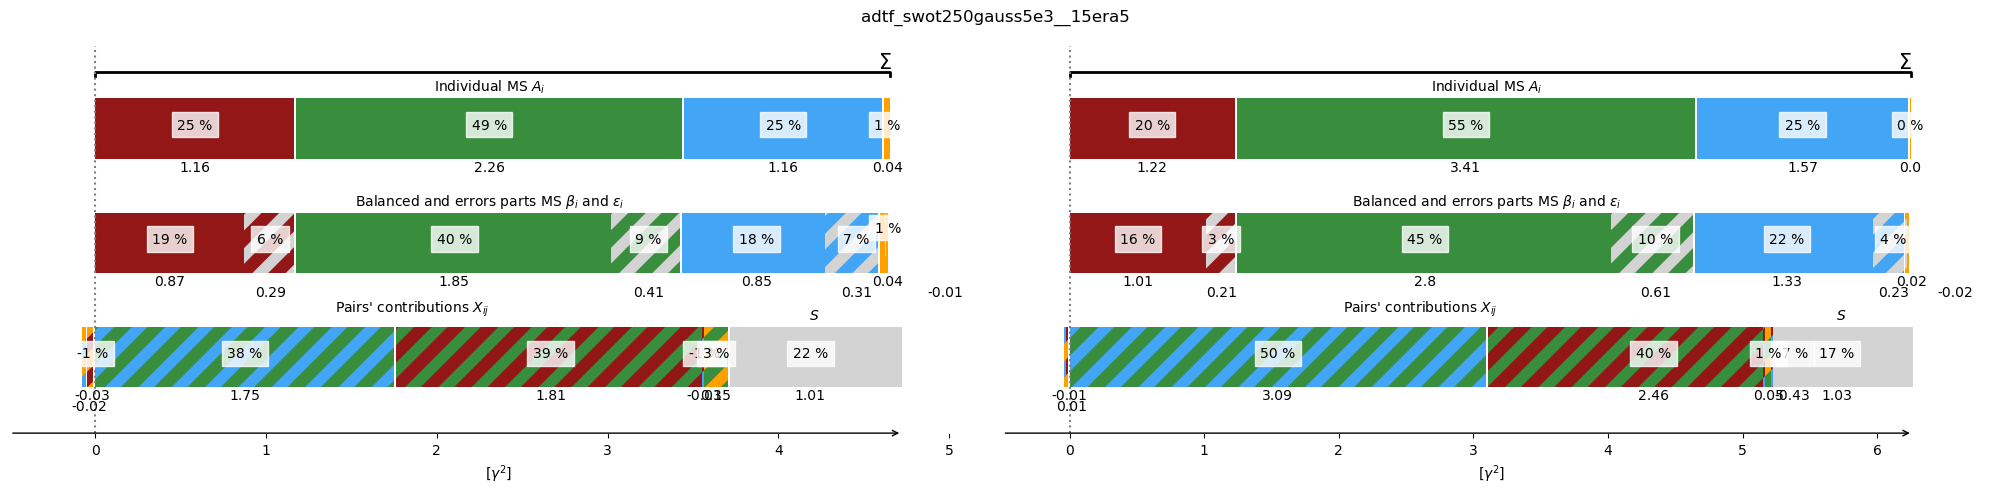

In [21]:
c = 'etaf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()

c = 'adtf_swot250gauss5e3__15era5'
fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False,)
synthetic_figure(df.loc[c], axs[0], dir='e')
synthetic_figure(df.loc[c], axs[1], dir='n')
fig.suptitle(c)
fig.tight_layout()